# CSE422 Lab Project
# Employee Attrition Prediction

**Dataset:** `employee_attriation_dataset.csv`

This notebook follows the lab report template section by section:

1. Introduction
2. Dataset Description
3. Dataset Pre-processing
4. Dataset Splitting
5. Model Training & Testing (Supervised + K-Means)
6. Model Selection / Comparison Analysis
7. Conclusion

Run the cells from top to bottom in order.

---
# 1. Introduction
---

Every company loses employees, but losing them **unexpectedly** is expensive. Hiring a
replacement, running interviews and getting a new person up to speed costs the company
both money and time, and the team loses the knowledge the old employee had.

The goal of this project is to look at HR records of employees and predict whether an
employee is likely to **leave the company (attrition)** or **stay**. If HR can flag the
risky employees early, they get a chance to act first, maybe by fixing the workload,
reviewing the salary or offering a promotion.

**The problem we are solving:** given the profile of an employee (age, income, job role,
overtime, satisfaction scores, years at the company etc.), predict the value of the
`Attrition` column, where `1` means the employee left and `0` means the employee stayed.

**Motivation:** attrition is a real and costly HR problem, the dataset has a good mix of
numerical and categorical features, and the target is a clean binary label, so it is a
good fit for the classification models covered in this course.

---
## Setup: libraries and dataset loading
---

In [ ]:
# Core libraries used throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")   # keeps the output clean from sklearn version warnings

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 12

# Fixing the seed so the results stay the same every time the notebook is re-run
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the dataset.
# If the file is already sitting beside the notebook this just works.
# Otherwise Colab will ask you to upload it.

import os

FILE_NAME = "employee_attriation_dataset.csv"

if not os.path.exists(FILE_NAME):
    from google.colab import files
    uploaded = files.upload()
    FILE_NAME = list(uploaded.keys())[0]

df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0], " Columns:", df.shape[1])
df.head()

Saving employee attriation dataset.csv to employee attriation dataset (1).csv
Dataset loaded successfully.
Rows: 1677  Columns: 35


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,...,80,1,10,2,3,10,0,7,8,0
1,1,35,Travel_Rarely,921,Sales,8,3,Other,1,1,...,80,1,4,3,3,4,2,0,3,0
2,2,32,Travel_Rarely,718,Sales,26,3,Marketing,1,3,...,80,2,4,3,3,3,2,1,2,0
3,3,38,Travel_Rarely,1488,Research & Development,2,3,Medical,1,3,...,80,0,15,1,1,6,0,0,2,0
4,4,50,Travel_Rarely,1017,Research & Development,5,4,Medical,1,2,...,80,0,31,0,3,31,14,4,10,1


---
# 2. Exploratory Data Analysis (EDA) and Dataset Description
---

## 2.1 How many data points and how many features?

In [ ]:
print("Total data points (rows) :", df.shape[0])
print("Total columns            :", df.shape[1])
print("Input features           :", df.shape[1] - 1, " (every column except the target)")
print("Output feature (target)  : Attrition")

Total data points (rows) : 1677
Total columns            : 35
Input features           : 34  (every column except the target)
Output feature (target)  : Attrition


## 2.2 Is this a classification or a regression problem?

In [ ]:
# The type of problem depends entirely on what the target column looks like.
print("Unique values in the target column 'Attrition':", sorted(df["Attrition"].unique()))
print("Number of unique values                       :", df["Attrition"].nunique())
print("Data type                                     :", df["Attrition"].dtype)
print()
print(df["Attrition"].value_counts().to_string())

print("""
--------------------------------------------------------------------
This is a CLASSIFICATION problem.

The target 'Attrition' only takes two discrete values, 0 and 1.
0 = the employee stayed, 1 = the employee left.

There is no in-between value. An answer like 0.63 would be meaningless
here, because an employee cannot partially leave the company. We are
sorting employees into two labelled groups, which is exactly what
classification does. Since there are only two groups, it is a
BINARY classification problem.

Regression would only apply if the target were a continuous number,
for example predicting MonthlyIncome or the number of years an
employee will stay.
--------------------------------------------------------------------
""")

Unique values in the target column 'Attrition': [np.int64(0), np.int64(1)]
Number of unique values                       : 2
Data type                                     : int64

Attrition
0    1477
1     200

--------------------------------------------------------------------
This is a CLASSIFICATION problem.

The target 'Attrition' only takes two discrete values, 0 and 1.
0 = the employee stayed, 1 = the employee left.

There is no in-between value. An answer like 0.63 would be meaningless
here, because an employee cannot partially leave the company. We are
sorting employees into two labelled groups, which is exactly what
classification does. Since there are only two groups, it is a
BINARY classification problem.

Regression would only apply if the target were a continuous number,
for example predicting MonthlyIncome or the number of years an
employee will stay.
--------------------------------------------------------------------



## 2.3 What kind of features are in the dataset? (Quantitative / Categorical)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1677 entries, 0 to 1676
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1677 non-null   int64 
 1   Age                       1677 non-null   int64 
 2   BusinessTravel            1677 non-null   object
 3   DailyRate                 1677 non-null   int64 
 4   Department                1677 non-null   object
 5   DistanceFromHome          1677 non-null   int64 
 6   Education                 1677 non-null   int64 
 7   EducationField            1677 non-null   object
 8   EmployeeCount             1677 non-null   int64 
 9   EnvironmentSatisfaction   1677 non-null   int64 
 10  Gender                    1677 non-null   object
 11  HourlyRate                1677 non-null   int64 
 12  JobInvolvement            1677 non-null   int64 
 13  JobLevel                  1677 non-null   int64 
 14  JobRole                 

In [ ]:
# Splitting the columns into numerical and categorical groups so we can
# summarise and plot each group in the way that suits it.

numerical_data = df.select_dtypes(include="number")
categorical_data = df.select_dtypes(include="object")

numerical_features = numerical_data.columns.tolist()
categorical_features = categorical_data.columns.tolist()

print(f"There are {len(numerical_features)} QUANTITATIVE (numerical) features:")
print(numerical_features)
print()
print(f"There are {len(categorical_features)} CATEGORICAL (text) features:")
print(categorical_features)

There are 27 QUANTITATIVE (numerical) features:
['id', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']

There are 8 CATEGORICAL (text) features:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [ ]:
# Summary statistics of the numerical features
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1677.0,838.000000,484.252517,0.0,419.0,838.0,1257.0,1676.0
Age,1677.0,36.036971,8.507112,18.0,30.0,35.0,41.0,60.0
DailyRate,1677.0,892.749553,374.496259,107.0,589.0,890.0,1223.0,3921.0
DistanceFromHome,1677.0,8.683959,7.826143,1.0,2.0,7.0,12.0,29.0
Education,1677.0,2.937984,1.039078,1.0,2.0,3.0,4.0,15.0
EmployeeCount,1677.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
EnvironmentSatisfaction,1677.0,2.757901,1.086835,1.0,2.0,3.0,4.0,4.0
HourlyRate,1677.0,67.798450,19.435928,30.0,51.0,69.0,84.0,100.0
JobInvolvement,1677.0,2.782349,0.650664,1.0,2.0,3.0,3.0,4.0
JobLevel,1677.0,1.998807,1.083065,1.0,1.0,2.0,2.0,7.0


In [ ]:
# Summary statistics of the categorical features
categorical_data.describe().T

,count,unique,top,freq
BusinessTravel,1677,3,Travel_Rarely,1290
Department,1677,3,Research & Development,1167
EducationField,1677,6,Life Sciences,775
Gender,1677,2,Male,1064
JobRole,1677,9,Sales Executive,355
MaritalStatus,1677,3,Married,773
Over18,1677,1,Y,1677
OverTime,1677,2,No,1277


In [ ]:
# A note about the numerical columns: not all of them are truly continuous.
# Some are survey ratings stored as numbers, so they behave like ordered categories.

rating_like = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
               "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction",
               "StockOptionLevel", "WorkLifeBalance"]

print("Truly continuous / count-based numerical features:")
print([c for c in numerical_features if c not in rating_like + ["Attrition", "id"]])
print()
print("Numerical columns that are really ordinal RATINGS (1-5 scales):")
print(rating_like)

Truly continuous / count-based numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeCount', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Numerical columns that are really ordinal RATINGS (1-5 scales):
['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']


## 2.4 Do we need to encode the categorical variables? Why?

In [ ]:
print("Values inside each categorical column:\n")
for col in categorical_features:
    print(f"{col:<18} ({df[col].nunique()} unique) -> {list(df[col].unique())}")

print("""
--------------------------------------------------------------------
YES, the categorical variables must be encoded.

Reason: scikit-learn models are built on mathematics. KNN measures
distance between points, Logistic Regression multiplies each feature
by a weight, and a Neural Network does matrix multiplication. None of
these operations can be performed on a string like "Sales" or "Male",
so the model would simply throw an error.

Encoding converts these text labels into numbers while keeping the
information they carry. The encoding method is chosen per column,
which is explained in detail in Section 3.
--------------------------------------------------------------------
""")

Values inside each categorical column:

BusinessTravel     (3 unique) -> ['Travel_Frequently', 'Travel_Rarely', 'Non-Travel']
Department         (3 unique) -> ['Research & Development', 'Sales', 'Human Resources']
EducationField     (6 unique) -> ['Medical', 'Other', 'Marketing', 'Life Sciences', 'Technical Degree', 'Human Resources']
Gender             (2 unique) -> ['Male', 'Female']
JobRole            (9 unique) -> ['Laboratory Technician', 'Sales Representative', 'Sales Executive', 'Healthcare Representative', 'Manager', 'Manufacturing Director', 'Research Scientist', 'Human Resources', 'Research Director']
MaritalStatus      (3 unique) -> ['Married', 'Divorced', 'Single']
Over18             (1 unique) -> ['Y']
OverTime           (2 unique) -> ['Yes', 'No']

--------------------------------------------------------------------
YES, the categorical variables must be encoded.

Reason: scikit-learn models are built on mathematics. KNN measures
distance between points, Logistic Regressi

## 2.5 Checking for constant, duplicate and invalid values

In [ ]:
# How many distinct values each column holds
print("Unique value count per column:\n")
print(df.nunique().to_string())

constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("\nColumns that hold the SAME value in every single row:", constant_cols)
print("These carry zero information and will be removed in Section 3.")

Unique value count per column:

id                          1677
Age                           43
BusinessTravel                 3
DailyRate                    625
Department                     3
DistanceFromHome              29
Education                      6
EducationField                 6
EmployeeCount                  1
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       6
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome                895
MonthlyRate                  903
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             41
TrainingTimesLastYear          7
WorkLifeBal

In [ ]:
# Standard missing value check
print("Missing values per column:\n")
print(df.isnull().sum().to_string())
print("\nTotal missing cells:", df.isnull().sum().sum())
print("Duplicate rows (ignoring the id column):", df.drop(columns=["id"]).duplicated().sum())

Missing values per column:

id                          0
Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLa

In [ ]:
# isnull() only catches blank cells. A value can also be "missing" in the sense that it is
# impossible. The survey columns in this dataset have documented valid ranges, so anything
# outside that range is a data entry error hiding as a normal number.

expected_ranges = {
    "Education": (1, 5),
    "JobLevel": (1, 5),
    "EnvironmentSatisfaction": (1, 4),
    "JobSatisfaction": (1, 4),
    "JobInvolvement": (1, 4),
    "RelationshipSatisfaction": (1, 4),
    "WorkLifeBalance": (1, 4),
    "PerformanceRating": (1, 4),
    "DailyRate": (1, 1499),
    "Age": (18, 60),
}

print("Checking each rating column against its documented valid range:\n")
for col, (low, high) in expected_ranges.items():
    bad = df[(df[col] < low) | (df[col] > high)]
    if len(bad) > 0:
        print(f"  {col:<26} valid {low}-{high}  ->  {len(bad)} INVALID value(s): {bad[col].tolist()}")
    else:
        print(f"  {col:<26} valid {low}-{high}  ->  ok")

print("\nLogical consistency checks:")
print("  Rows where TotalWorkingYears > Age           :", (df["TotalWorkingYears"] > df["Age"]).sum())
print("  Rows where YearsAtCompany > TotalWorkingYears:", (df["YearsAtCompany"] > df["TotalWorkingYears"]).sum())

Checking each rating column against its documented valid range:

  Education                  valid 1-5  ->  1 INVALID value(s): [15]
  JobLevel                   valid 1-5  ->  1 INVALID value(s): [7]
  EnvironmentSatisfaction    valid 1-4  ->  ok
  JobSatisfaction            valid 1-4  ->  ok
  JobInvolvement             valid 1-4  ->  ok
  RelationshipSatisfaction   valid 1-4  ->  ok
  WorkLifeBalance            valid 1-4  ->  ok
  PerformanceRating          valid 1-4  ->  ok
  DailyRate                  valid 1-1499  ->  1 INVALID value(s): [3921]
  Age                        valid 18-60  ->  ok

Logical consistency checks:
  Rows where TotalWorkingYears > Age           : 1
  Rows where YearsAtCompany > TotalWorkingYears: 2


## 2.6 Distribution of the numerical features

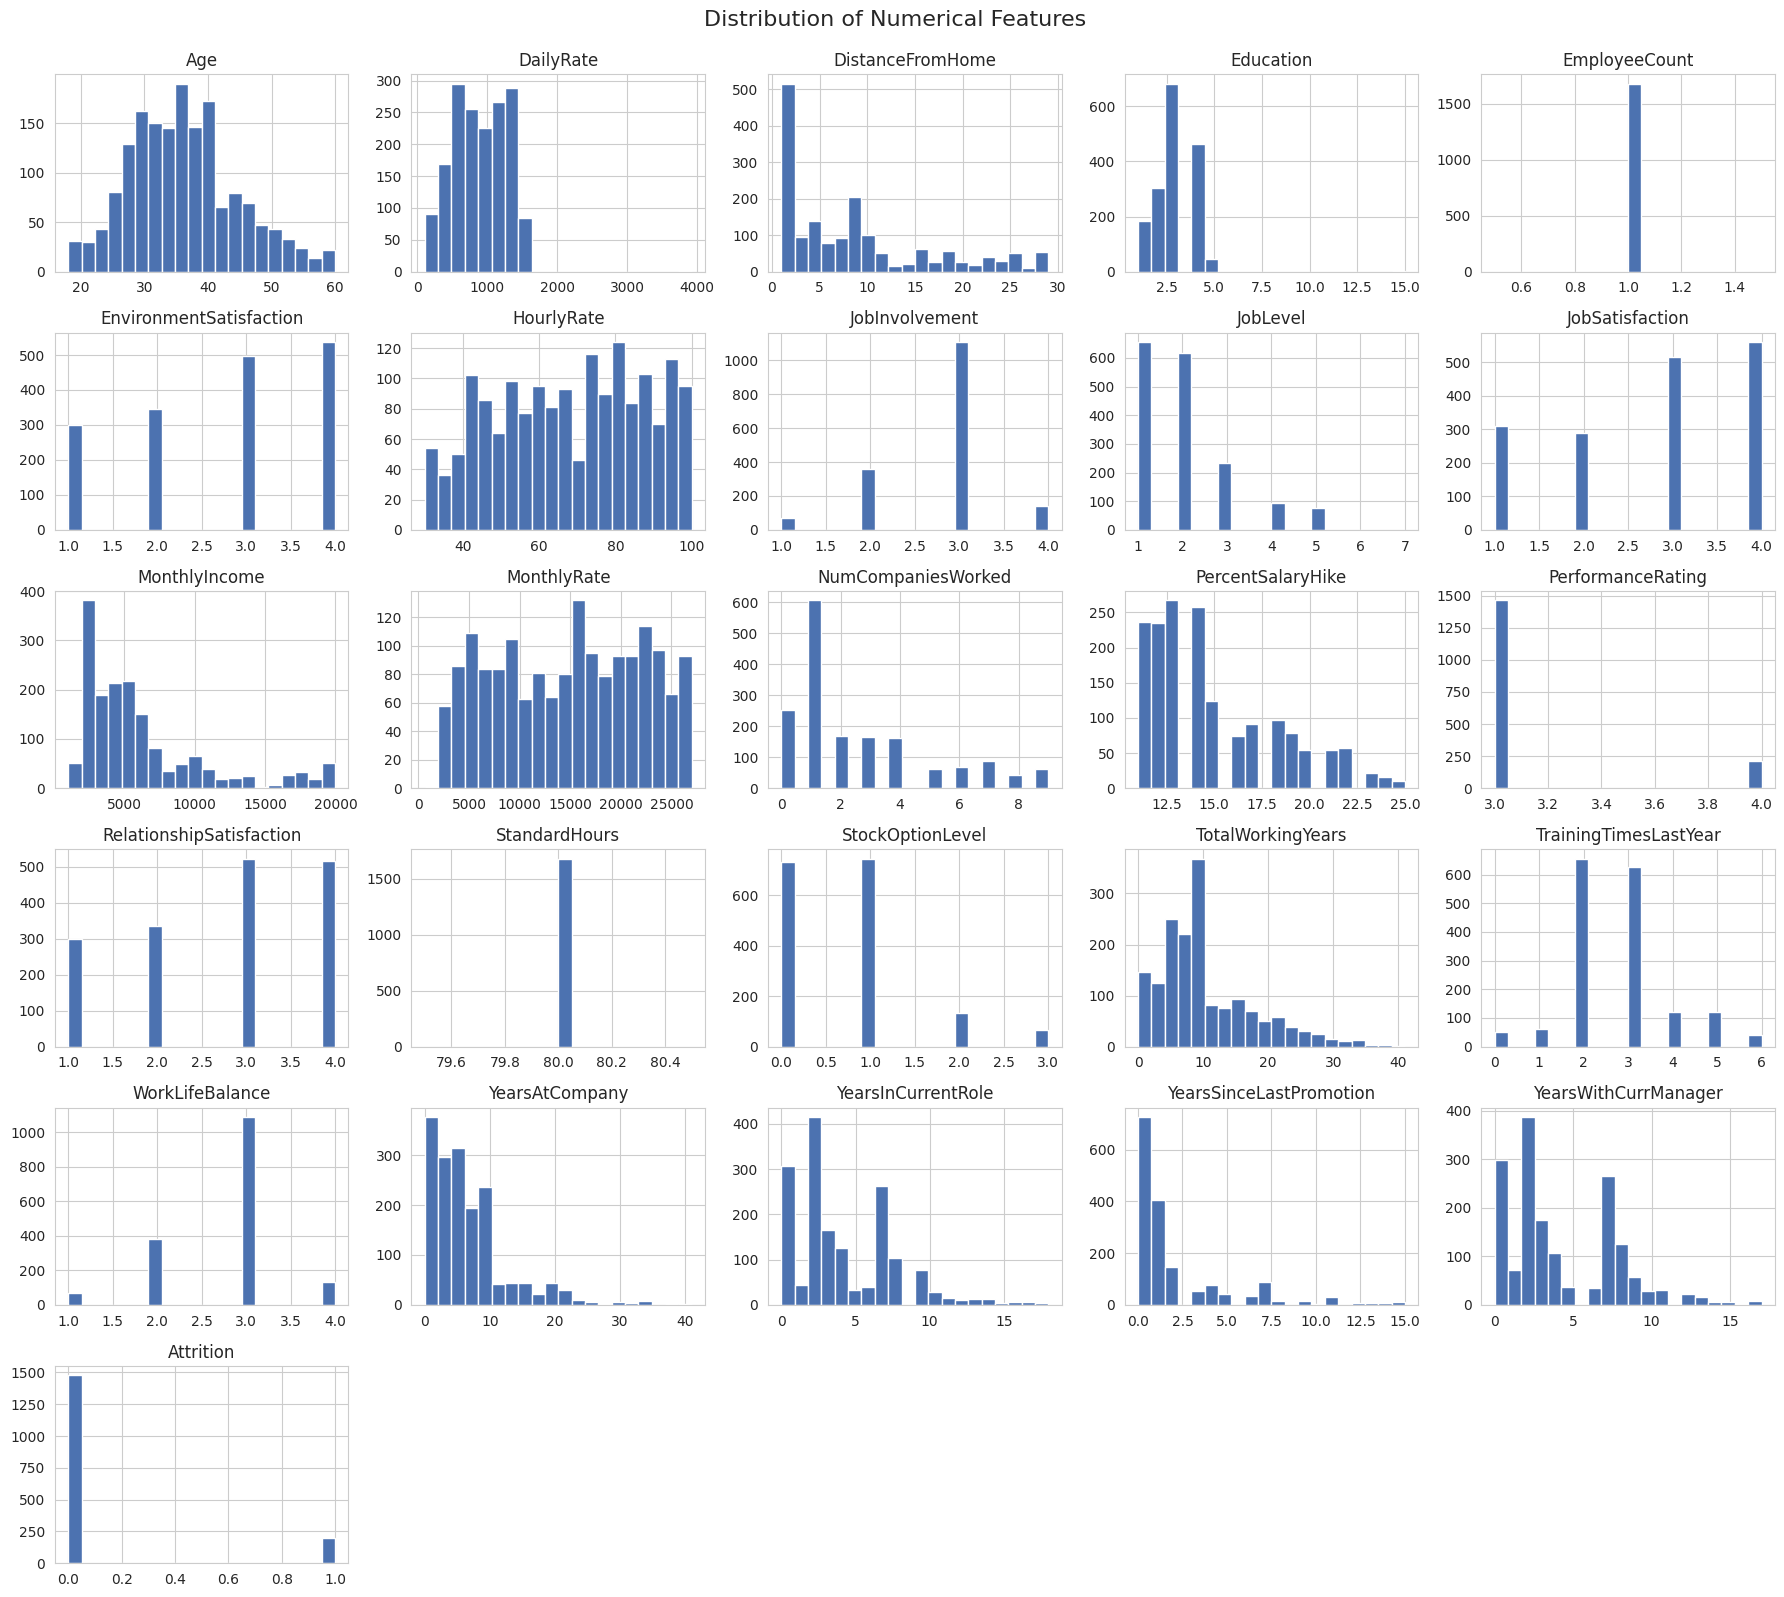

In [ ]:
# Histograms show the shape of every numerical feature at a glance
numerical_data.drop(columns=["id"]).hist(figsize=(18, 16), bins=20,
                                         color="#4C72B0", edgecolor="white")
plt.suptitle("Distribution of Numerical Features", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

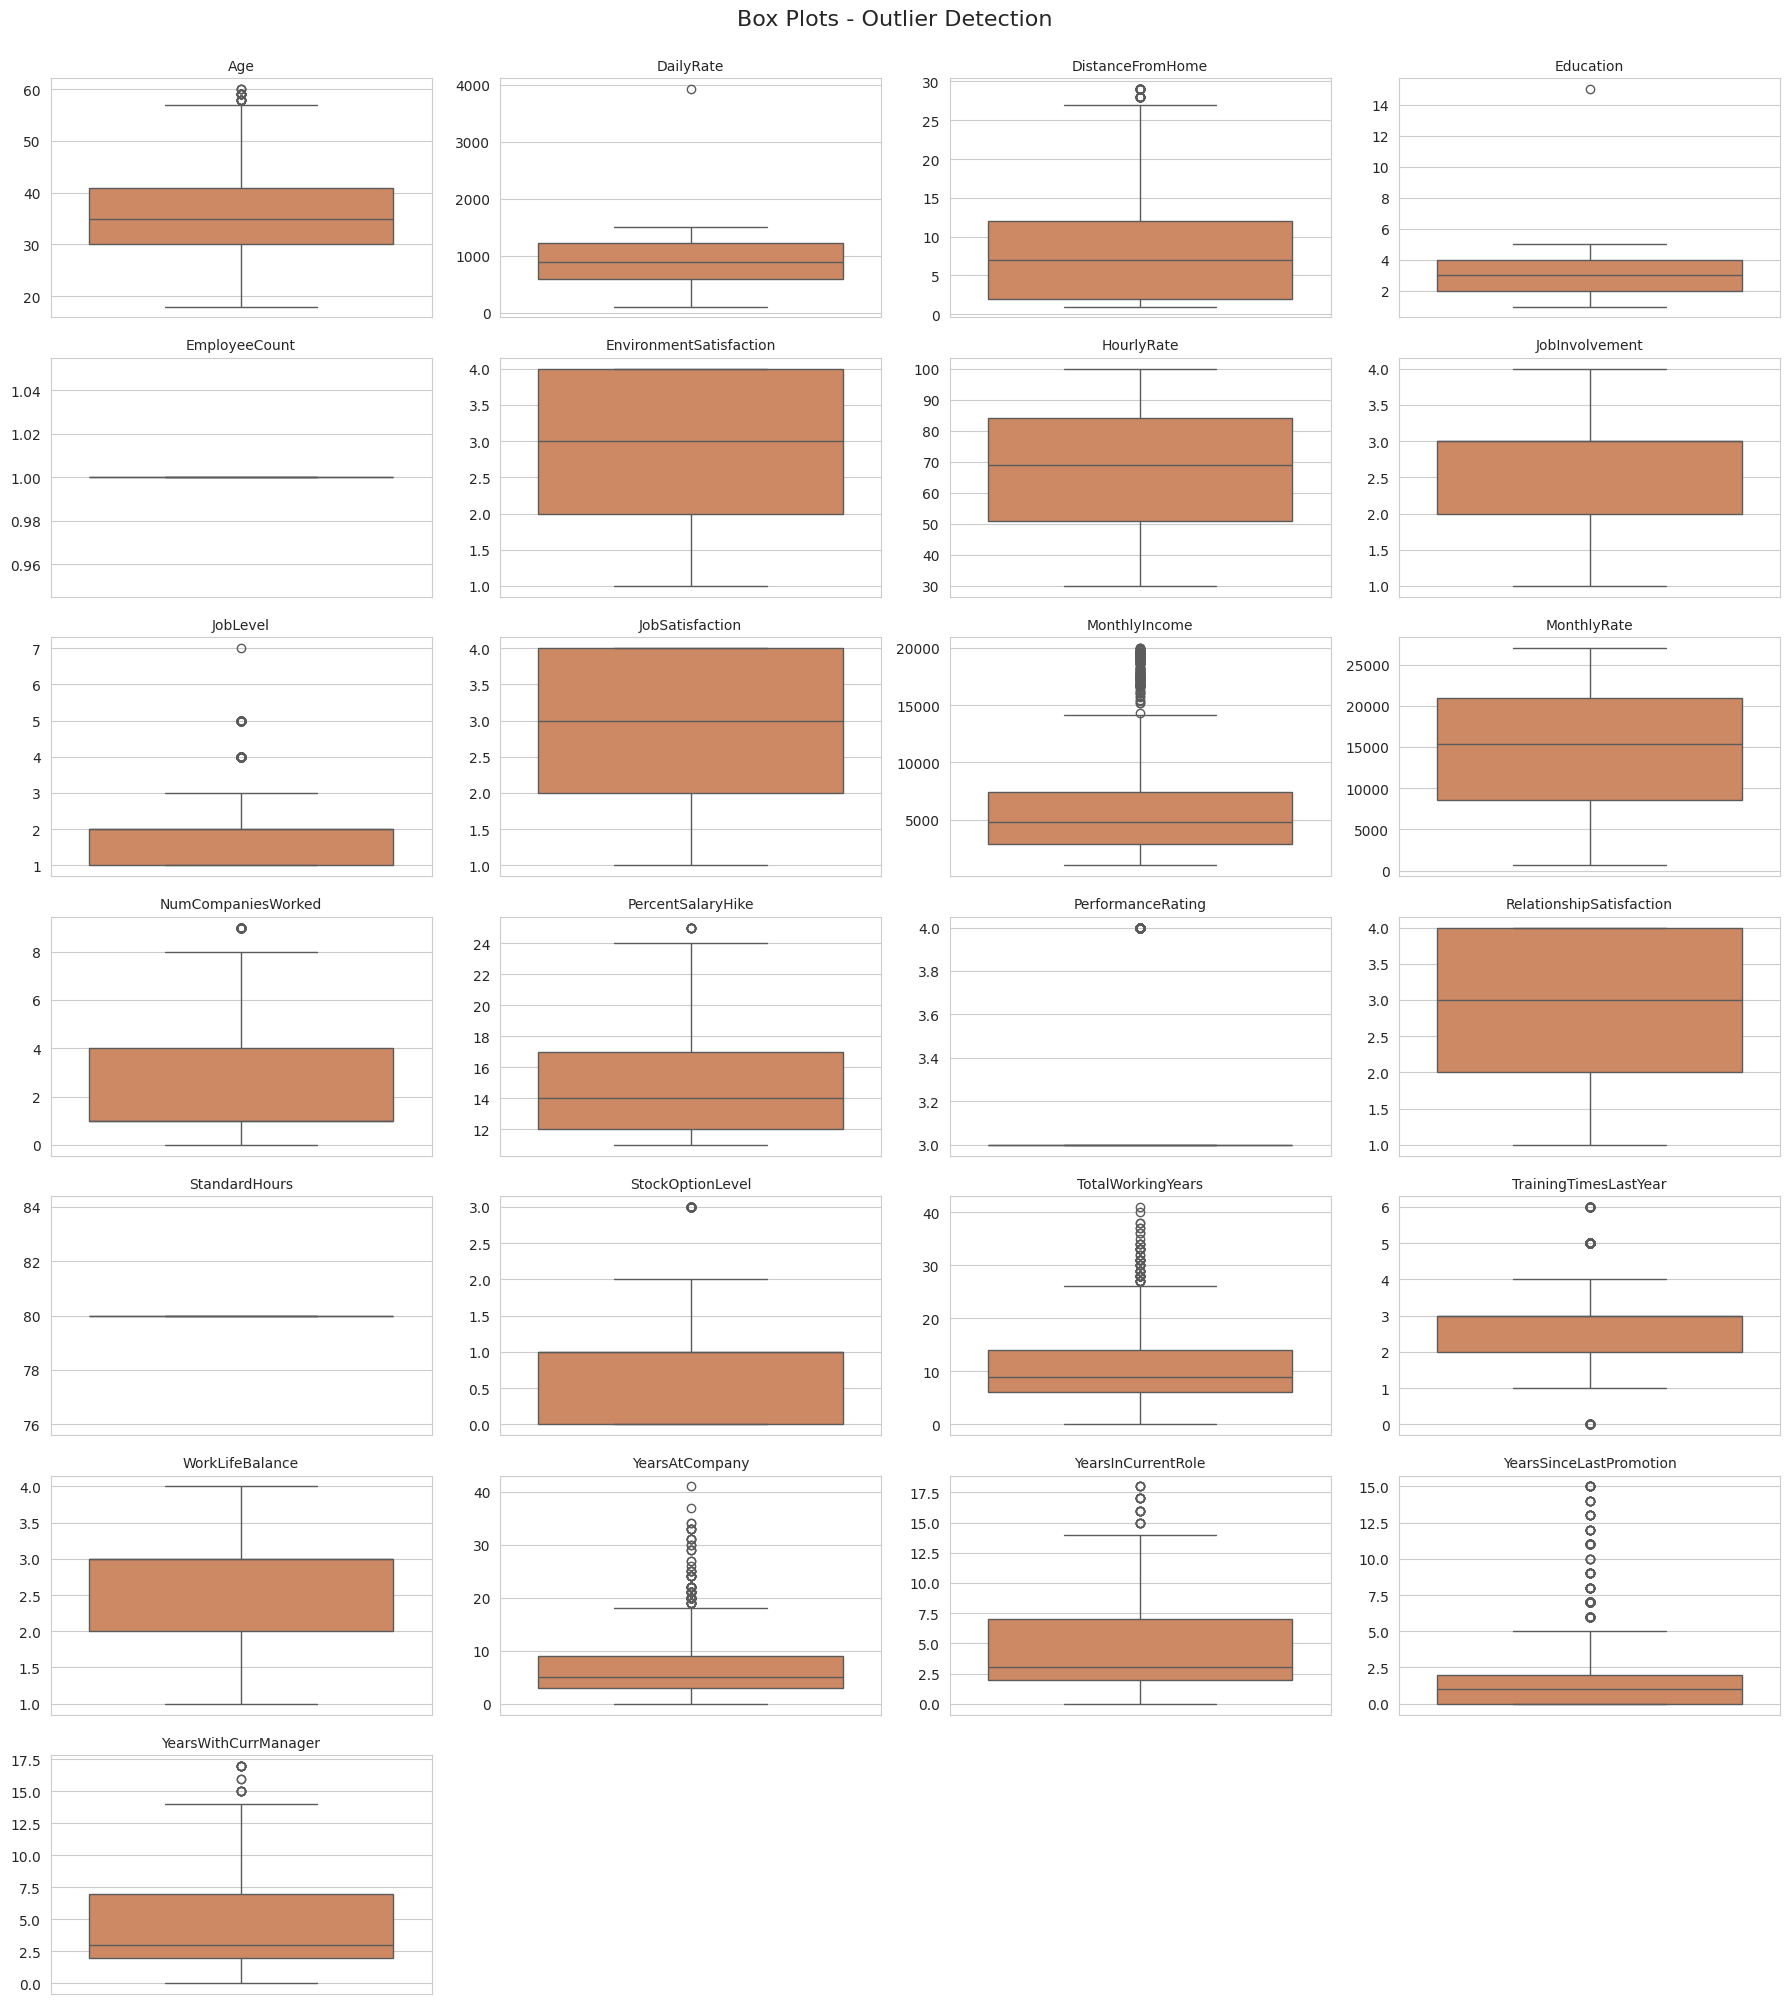

In [ ]:
# Box plots are the quickest way to spot outliers
plot_cols = [c for c in numerical_features if c not in ["id", "Attrition"]]

fig, axes = plt.subplots(7, 4, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#DD8452")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("")

for j in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Box Plots - Outlier Detection", fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

## 2.7 Distribution of the categorical features

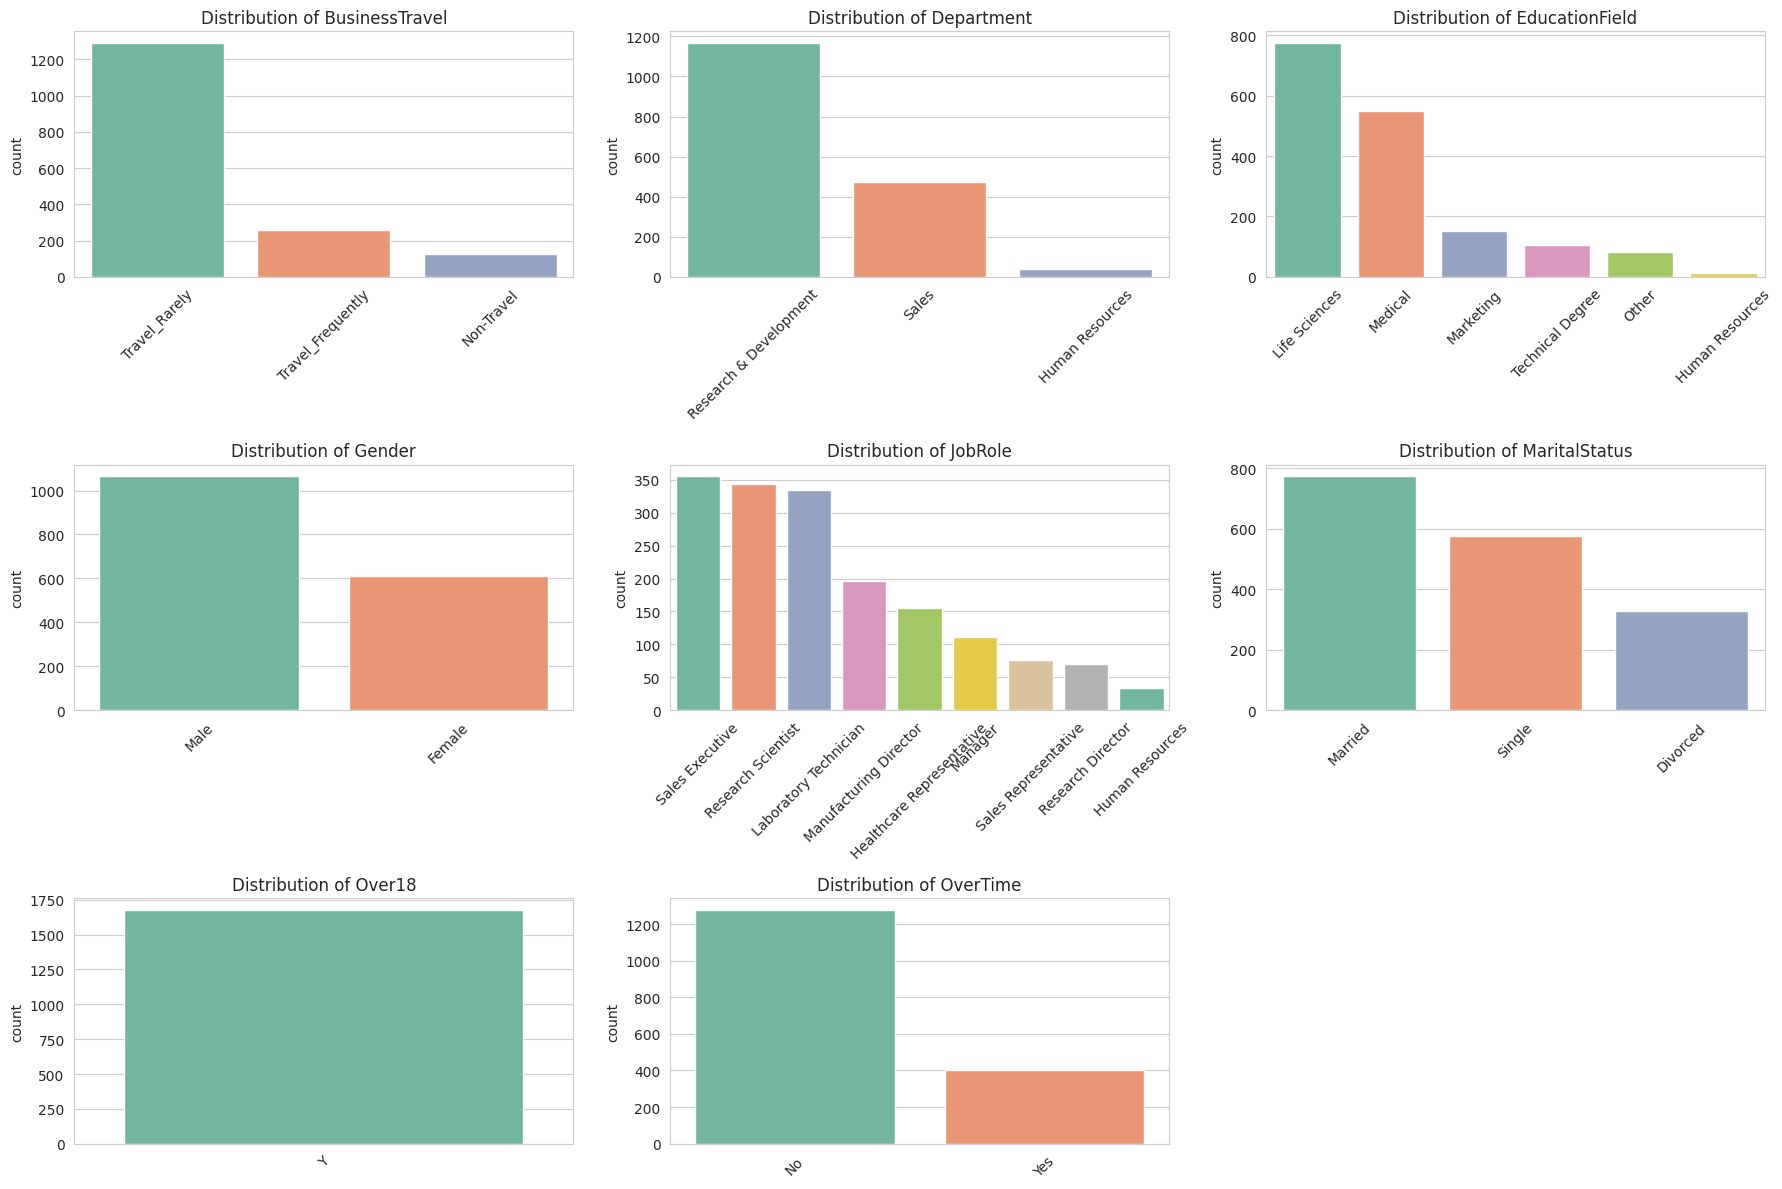

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].set_xlabel("")

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2.8 Correlation of all the features (input and output) — Heatmap

In [ ]:
# Correlation is a numbers-only operation, so the text columns get a temporary
# numeric code just for this test. The real encoding happens in Section 3.
# The constant columns are dropped here because a column with zero variance
# has an undefined correlation and would show up as blank NaN cells.

df_for_corr = df.drop(columns=["id"] + constant_cols).copy()

for col in df_for_corr.select_dtypes(include="object").columns:
    df_for_corr[col] = df_for_corr[col].astype("category").cat.codes

correlation_matrix = df_for_corr.corr()
correlation_matrix.round(3)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
Age,1.000,0.017,0.040,-0.015,-0.049,0.224,-0.018,0.030,-0.031,0.031,...,0.056,0.065,0.648,0.014,0.034,0.307,0.220,0.204,0.202,-0.161
BusinessTravel,0.017,1.000,-0.016,-0.020,0.006,-0.019,0.004,-0.002,-0.020,0.052,...,-0.013,-0.047,0.008,0.031,-0.012,-0.040,-0.080,-0.021,-0.065,0.001
DailyRate,0.040,-0.016,1.000,0.025,0.024,-0.007,-0.021,0.006,0.015,-0.001,...,0.001,0.021,0.058,-0.023,0.025,0.066,0.057,0.037,0.041,-0.022
Department,-0.015,-0.020,0.025,1.000,0.030,0.014,-0.066,-0.000,-0.021,0.001,...,0.002,-0.006,0.021,0.046,-0.012,0.022,0.030,0.053,0.042,0.032
DistanceFromHome,-0.049,0.006,0.024,0.030,1.000,-0.011,-0.023,0.005,-0.003,0.006,...,-0.012,0.039,-0.034,-0.000,-0.017,-0.024,-0.007,-0.004,0.014,0.025
Education,0.224,-0.019,-0.007,0.014,-0.011,1.000,-0.020,-0.011,0.027,0.015,...,-0.005,0.042,0.153,-0.012,-0.010,0.117,0.094,0.050,0.110,-0.084
EducationField,-0.018,0.004,-0.021,-0.066,-0.023,-0.020,1.000,0.028,-0.037,-0.061,...,0.000,-0.017,-0.008,0.070,0.008,0.012,0.026,-0.001,-0.001,-0.007
EnvironmentSatisfaction,0.030,-0.002,0.006,-0.000,0.005,-0.011,0.028,1.000,-0.039,0.010,...,-0.036,0.002,0.022,-0.029,0.045,0.009,0.017,0.029,0.023,-0.092
Gender,-0.031,-0.020,0.015,-0.021,-0.003,0.027,-0.037,-0.039,1.000,0.010,...,-0.035,0.036,-0.105,0.027,0.027,-0.047,-0.013,-0.029,-0.015,0.042
HourlyRate,0.031,0.052,-0.001,0.001,0.006,0.015,-0.061,0.010,0.010,1.000,...,-0.035,0.059,-0.025,0.040,0.017,-0.063,-0.064,-0.064,-0.075,-0.037


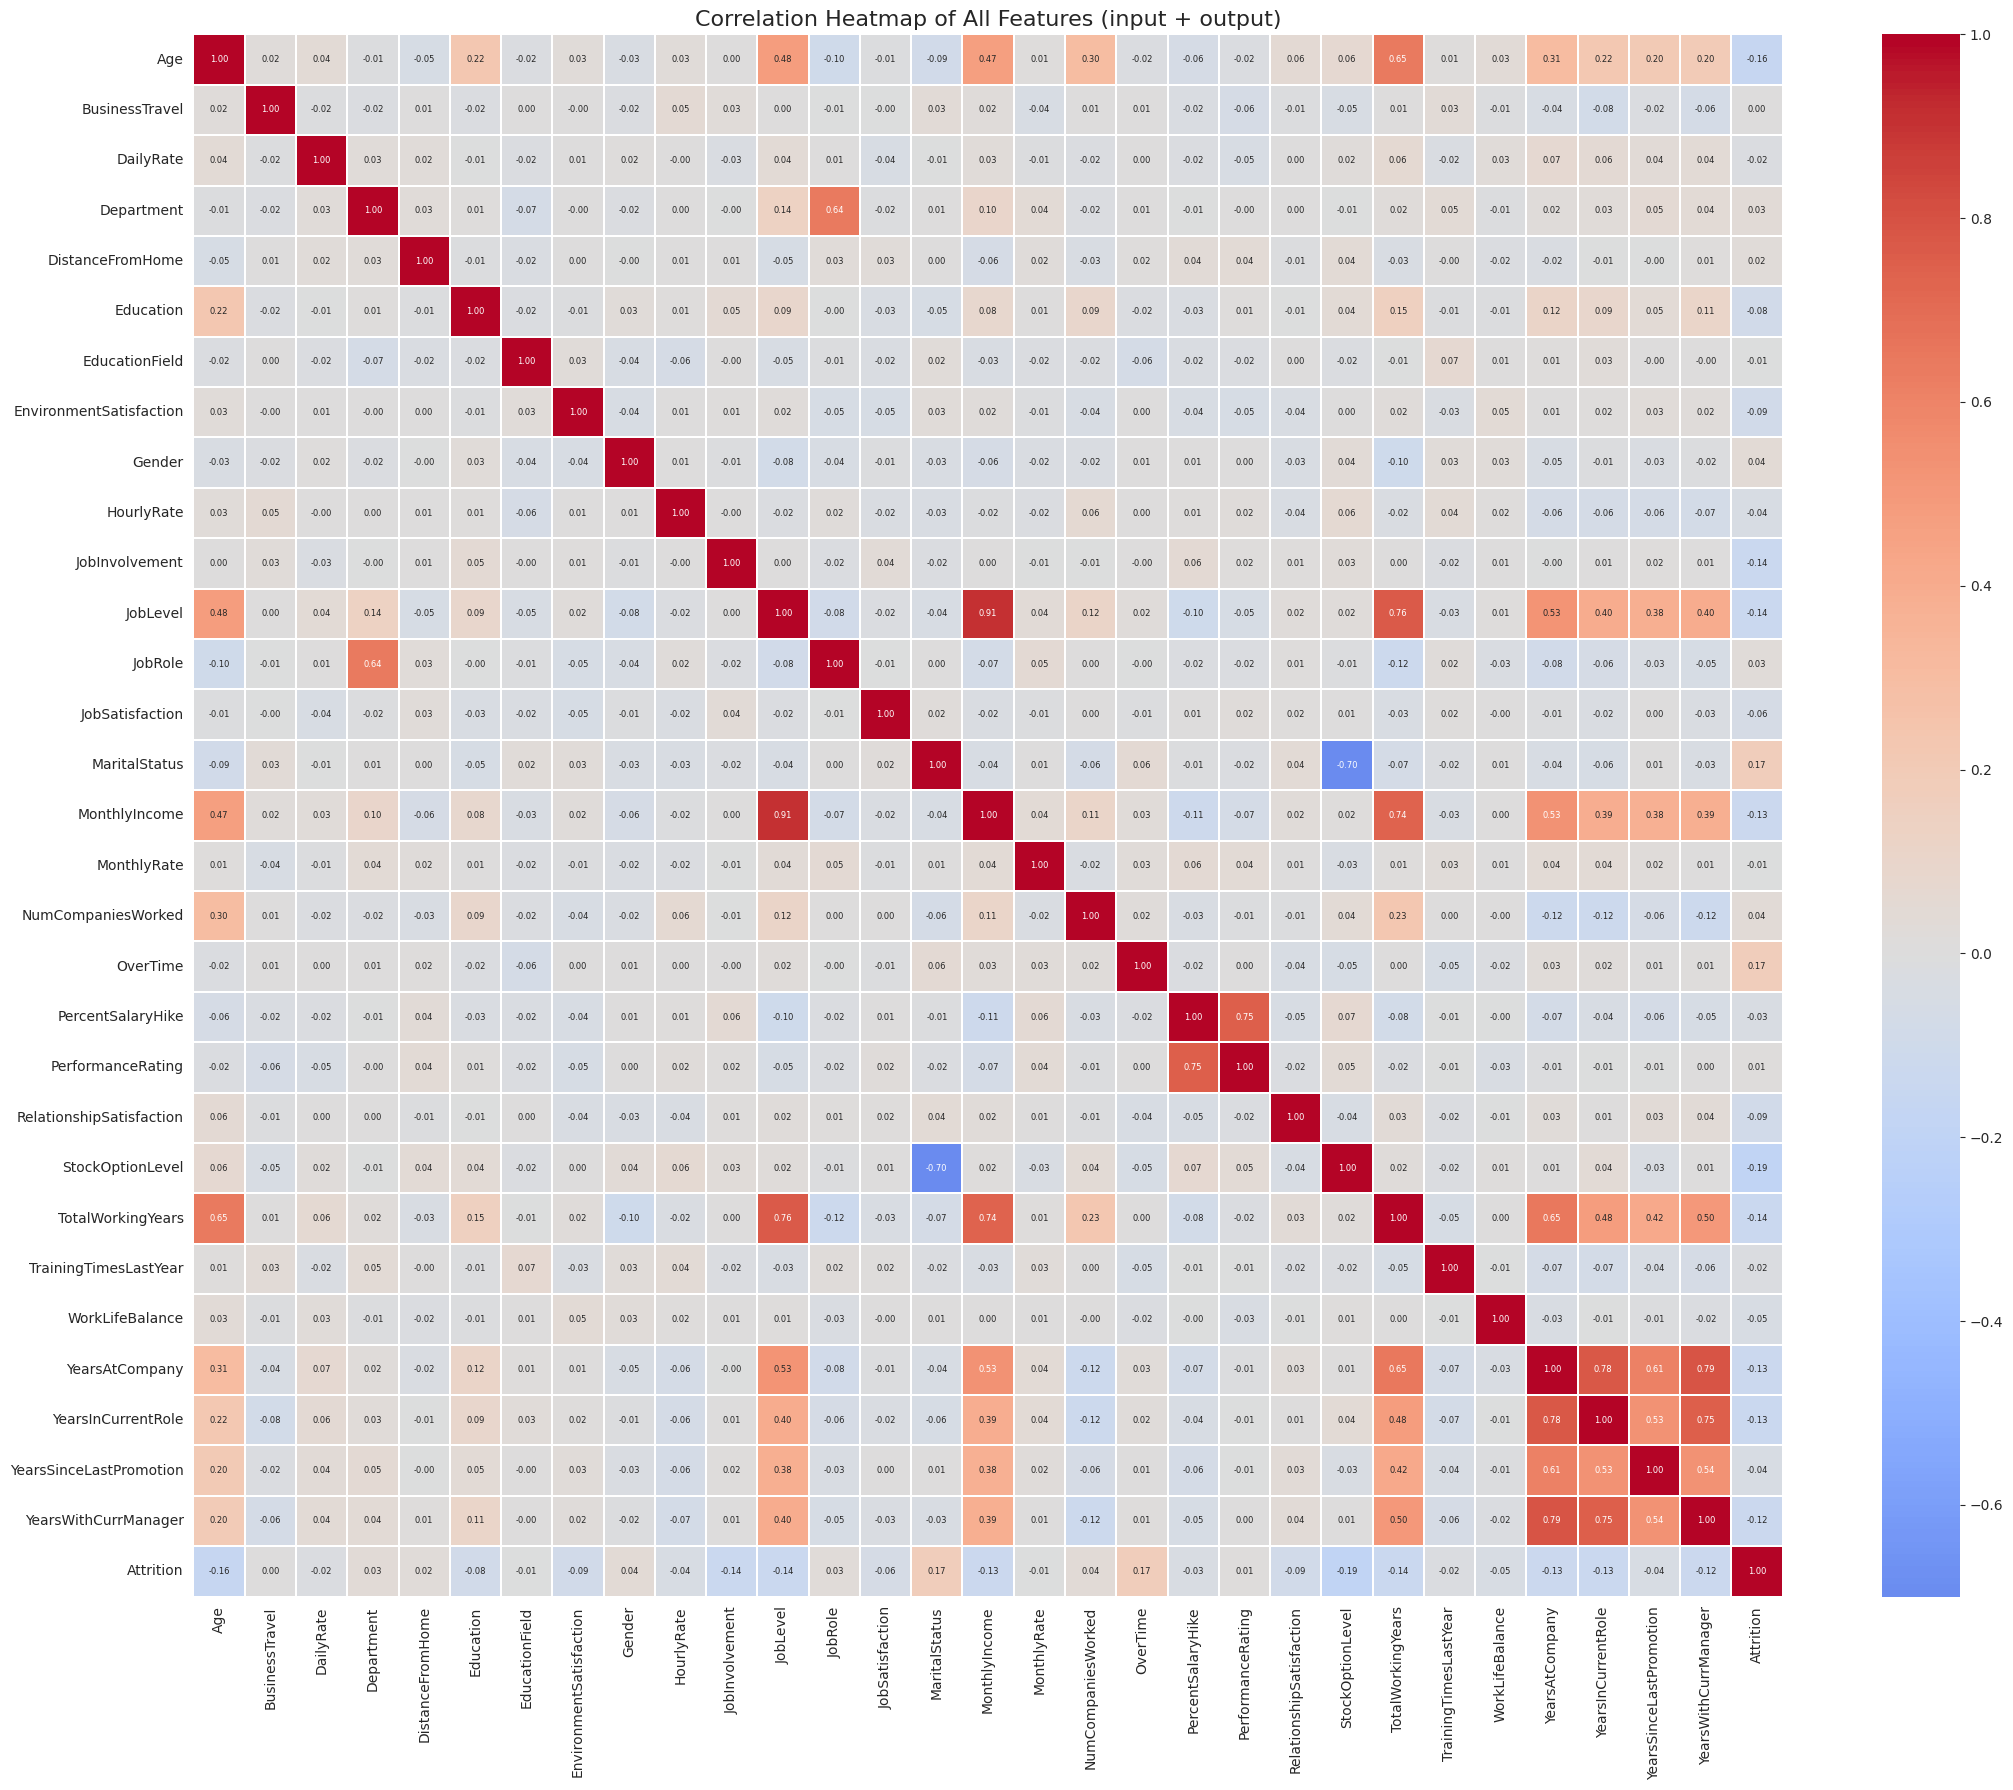

In [ ]:
plt.figure(figsize=(22, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.3, annot_kws={"size": 6}, center=0)
plt.title("Correlation Heatmap of All Features (input + output)", fontsize=16)
plt.tight_layout()
plt.show()

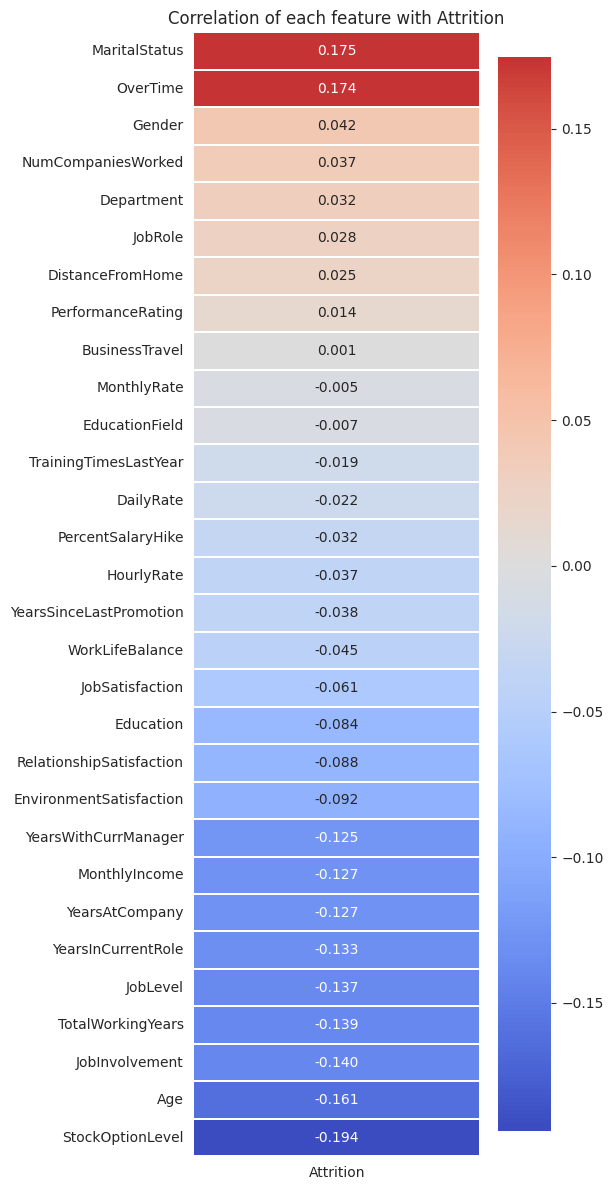

,Attrition
MaritalStatus,0.175
OverTime,0.174
Gender,0.042
NumCompaniesWorked,0.037
Department,0.032
JobRole,0.028
DistanceFromHome,0.025
PerformanceRating,0.014
BusinessTravel,0.001
MonthlyRate,-0.005


In [ ]:
# The full heatmap is dense, so here is the single column that matters most:
# how each feature relates to the target.

target_corr = (correlation_matrix[["Attrition"]]
               .drop(index="Attrition")
               .sort_values(by="Attrition", ascending=False))

plt.figure(figsize=(6, 12))
sns.heatmap(target_corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation of each feature with Attrition")
plt.tight_layout()
plt.show()

target_corr.round(3)

### What do we understand from the correlation test?

In [ ]:
print("TOP 5 features PUSHING employees towards leaving (positive correlation):")
print(target_corr.head(5).round(3).to_string())
print()
print("TOP 5 features KEEPING employees in the company (negative correlation):")
print(target_corr.tail(5).round(3).to_string())

print("""
--------------------------------------------------------------------
WHAT THE CORRELATION TEST TELLS US

1. No feature is strongly correlated with Attrition. Every value sits
   roughly between -0.20 and +0.18. That means no single column can
   predict attrition on its own, and we should expect the models to
   find this a genuinely difficult problem.

2. The strongest signals still make practical sense:
   - StockOptionLevel and MonthlyIncome are negative, so employees who
     are financially invested in the company tend to stay.
   - Age, TotalWorkingYears and YearsAtCompany are negative, so older
     and more settled employees leave less.
   - OverTime and MaritalStatus are positive, so overworked employees
     and single employees leave more often.

3. Because the correlations are weak but spread across many columns,
   we should keep most features rather than dropping them. The models
   will have to combine several weak signals instead of relying on one.

4. Correlation here only measures a straight-line relationship. A model
   like a Decision Tree or a Neural Network can still pick up patterns
   that this test cannot see.
--------------------------------------------------------------------
""")

TOP 5 features PUSHING employees towards leaving (positive correlation):
                    Attrition
MaritalStatus           0.175
OverTime                0.174
Gender                  0.042
NumCompaniesWorked      0.037
Department              0.032

TOP 5 features KEEPING employees in the company (negative correlation):
                   Attrition
JobLevel              -0.137
TotalWorkingYears     -0.139
JobInvolvement        -0.140
Age                   -0.161
StockOptionLevel      -0.194

--------------------------------------------------------------------
WHAT THE CORRELATION TEST TELLS US

1. No feature is strongly correlated with Attrition. Every value sits
   roughly between -0.20 and +0.18. That means no single column can
   predict attrition on its own, and we should expect the models to
   find this a genuinely difficult problem.

2. The strongest signals still make practical sense:
   - StockOptionLevel and MonthlyIncome are negative, so employees who
     are financiall

In [ ]:
# Checking whether any two INPUT features are telling us the same thing.
# Highly correlated pairs are redundant and can make linear models unstable.

upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)
high_pairs = high_pairs[abs(high_pairs) > 0.7]

print("Feature pairs correlated above 0.7 (possible redundancy):\n")
print(high_pairs.round(3).to_string())

print("""
These pairs are expected in HR data: a higher JobLevel naturally comes with a higher
MonthlyIncome, and someone with many YearsAtCompany usually has many
YearsWithCurrManager. We are keeping them, because tree based models and neural
networks handle correlated inputs well, but it is worth knowing that the logistic
regression coefficients for these columns should not be read individually.
""")

Feature pairs correlated above 0.7 (possible redundancy):

JobLevel            MonthlyIncome           0.910
YearsAtCompany      YearsWithCurrManager    0.792
                    YearsInCurrentRole      0.781
JobLevel            TotalWorkingYears       0.762
PercentSalaryHike   PerformanceRating       0.752
YearsInCurrentRole  YearsWithCurrManager    0.751
MonthlyIncome       TotalWorkingYears       0.741

These pairs are expected in HR data: a higher JobLevel naturally comes with a higher
MonthlyIncome, and someone with many YearsAtCompany usually has many
YearsWithCurrManager. We are keeping them, because tree based models and neural
networks handle correlated inputs well, but it is worth knowing that the logistic
regression coefficients for these columns should not be read individually.



## 2.9 Imbalanced Dataset check

In [ ]:
# Counting how many instances belong to each class of the output feature
class_counts = df.groupby("Attrition").size()

imbalance_df = pd.DataFrame({
    "Attrition": class_counts.index,
    "count": class_counts.values,
    "percentage": (class_counts.values / len(df) * 100).round(2)
})
imbalance_df["label"] = imbalance_df["Attrition"].map({0: "0 = Stayed", 1: "1 = Left"})

print(imbalance_df.to_string(index=False))

ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (majority : minority) = {ratio:.2f} : 1")

 Attrition  count  percentage      label
         0   1477       88.07 0 = Stayed
         1    200       11.93   1 = Left

Imbalance ratio (majority : minority) = 7.38 : 1


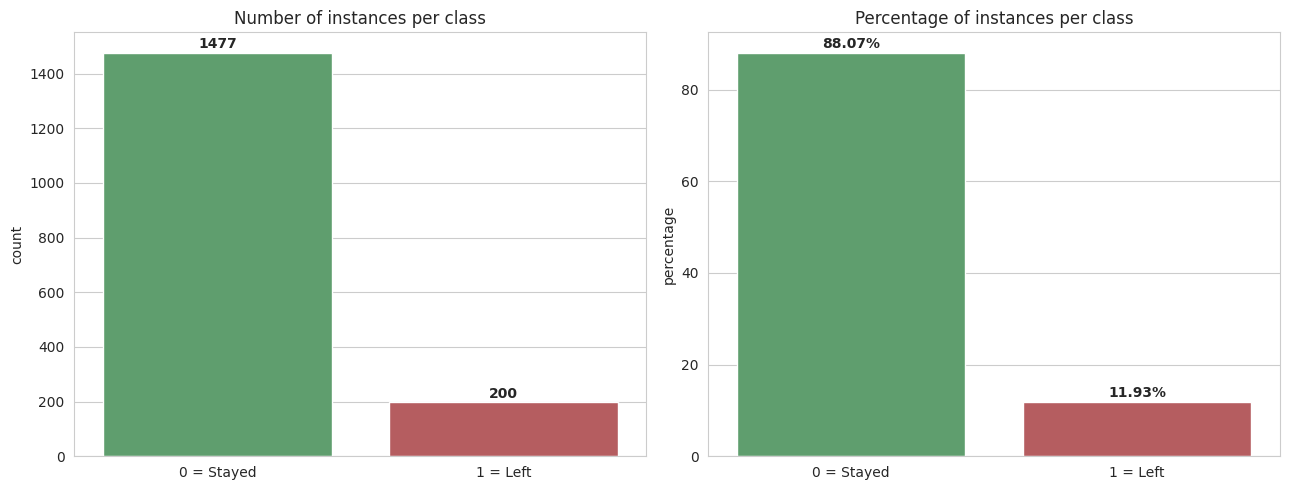

In [ ]:
# Bar chart of the N classes (here N = 2)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=imbalance_df, x="label", y="count", ax=axes[0], palette=["#55A868", "#C44E52"])
for i, v in enumerate(imbalance_df["count"]):
    axes[0].text(i, v + 15, str(v), ha="center", fontweight="bold")
axes[0].set_title("Number of instances per class")
axes[0].set_xlabel("")

sns.barplot(data=imbalance_df, x="label", y="percentage", ax=axes[1], palette=["#55A868", "#C44E52"])
for i, v in enumerate(imbalance_df["percentage"]):
    axes[1].text(i, v + 1, f"{v}%", ha="center", fontweight="bold")
axes[1].set_title("Percentage of instances per class")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**OBSERVATION: THE DATASET IS IMBALANCED**

The two classes do NOT have an equal number of instances.
About 88% of the rows are class 0 (stayed) and only about 12% are
class 1 (left), which is roughly a 7.4 : 1 ratio.

Why this matters:
A model can score 88% accuracy by lazily predicting "stayed" for every
single employee, without learning anything at all. That model would be
useless to HR, because it never catches the employees who are actually
about to leave, and those are the only ones we care about.

Because of this, accuracy alone is a misleading metric here. We will
also report PRECISION, RECALL, F1 and AUC in Section 6, and we will
rebalance the training data in Section 4.

## 2.10 EDA: extracting relationships

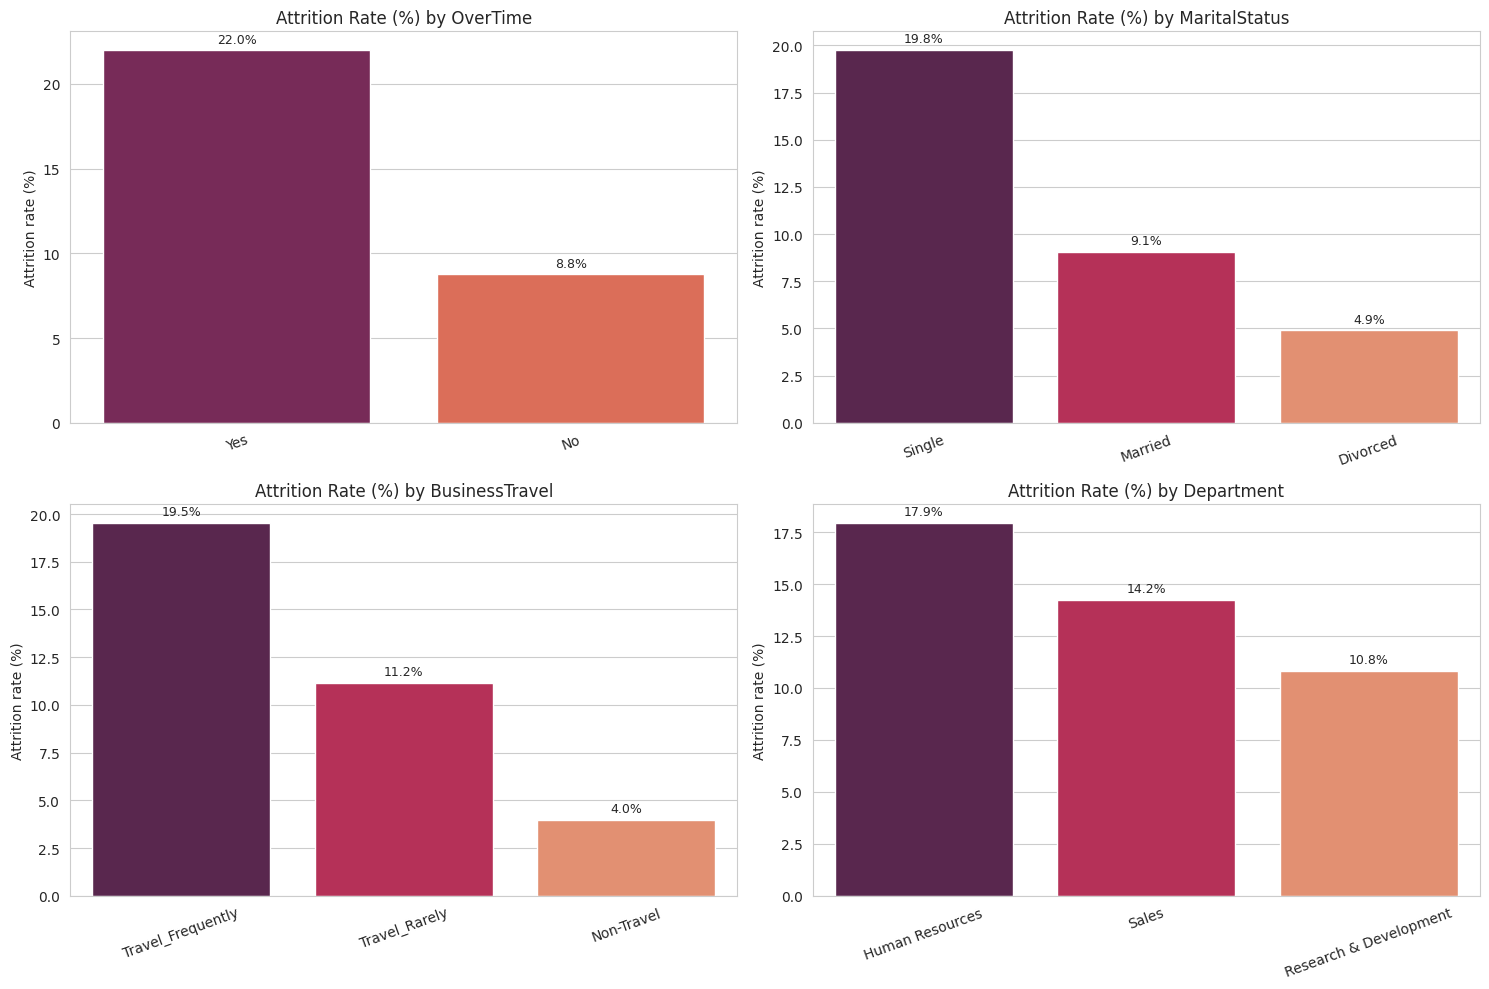

In [ ]:
# Attrition rate by the main categorical features.
# Because the target is 0/1, taking the mean of Attrition inside a group
# gives exactly the fraction of that group that left.

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.flatten(), ["OverTime", "MaritalStatus", "BusinessTravel", "Department"]):
    rate = df.groupby(col)["Attrition"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="rocket")
    ax.set_title(f"Attrition Rate (%) by {col}")
    ax.set_ylabel("Attrition rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

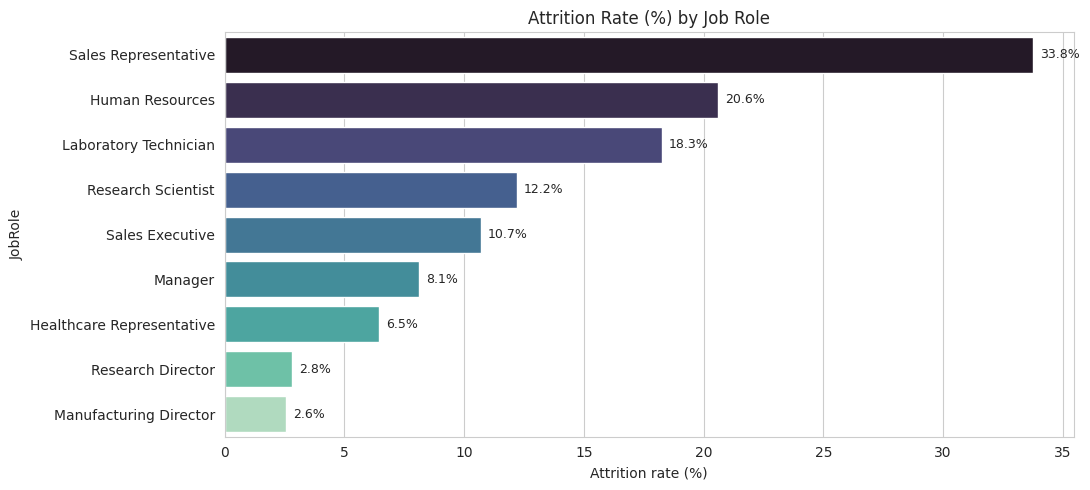

JobRole
Sales Representative         33.77
Human Resources              20.59
Laboratory Technician        18.26
Research Scientist           12.21
Sales Executive              10.70
Manager                       8.11
Healthcare Representative     6.45
Research Director             2.82
Manufacturing Director        2.55


In [ ]:
# Which job roles lose the most people
role_rate = (df.groupby("JobRole")["Attrition"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(x=role_rate.values, y=role_rate.index, palette="mako")
for i, v in enumerate(role_rate.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.title("Attrition Rate (%) by Job Role")
plt.xlabel("Attrition rate (%)")
plt.tight_layout()
plt.show()

print(role_rate.round(2).to_string())

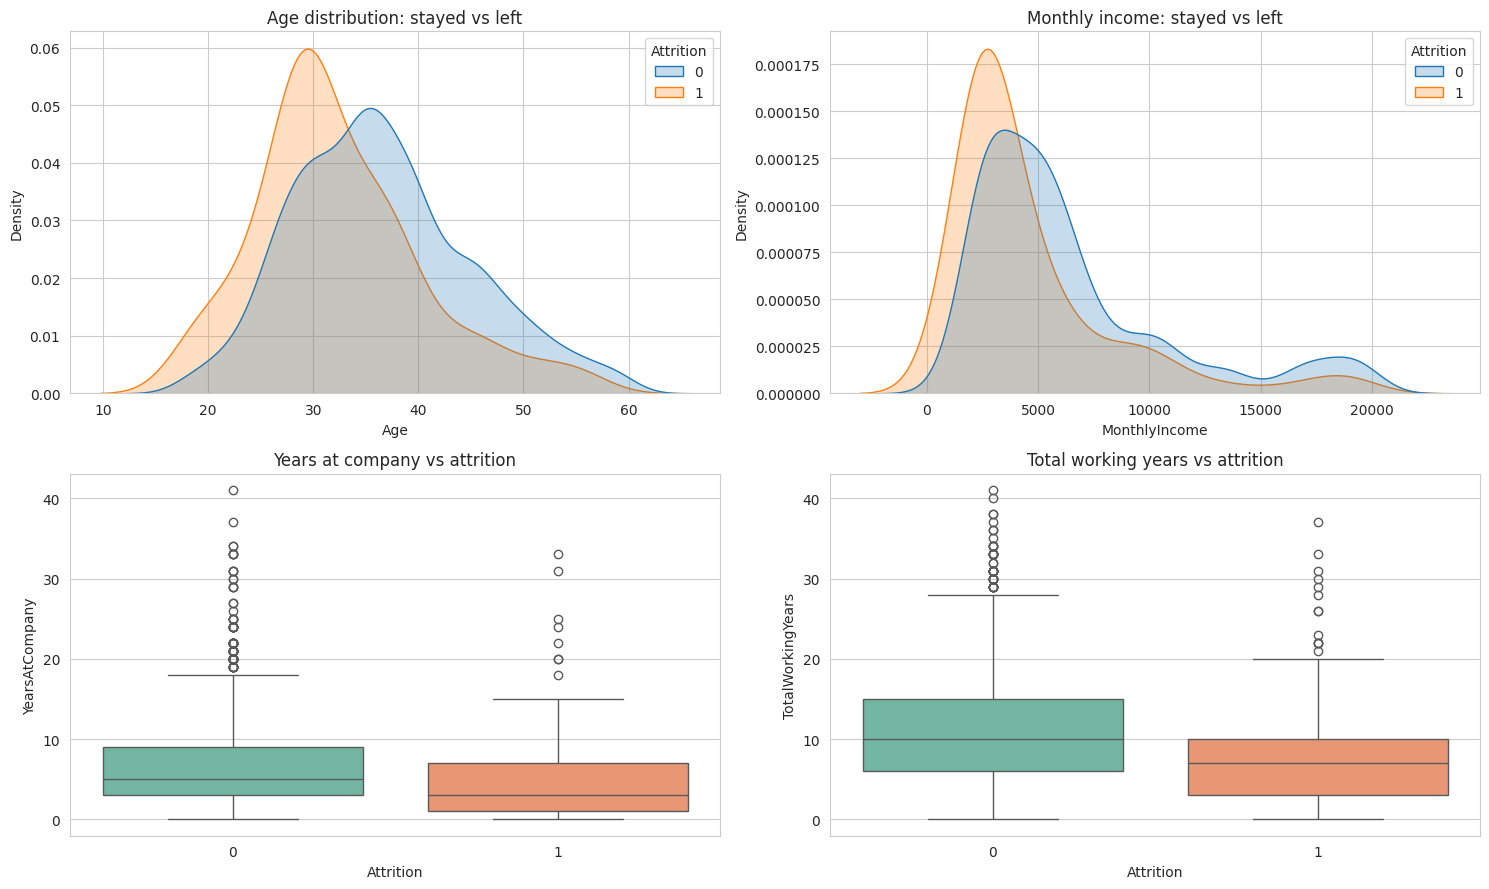

In [ ]:
# How age, income and tenure differ between the people who stayed and the people who left
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.kdeplot(data=df, x="Age", hue="Attrition", fill=True, common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Age distribution: stayed vs left")

sns.kdeplot(data=df, x="MonthlyIncome", hue="Attrition", fill=True, common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Monthly income: stayed vs left")

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Years at company vs attrition")

sns.boxplot(data=df, x="Attrition", y="TotalWorkingYears", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Total working years vs attrition")

plt.tight_layout()
plt.show()

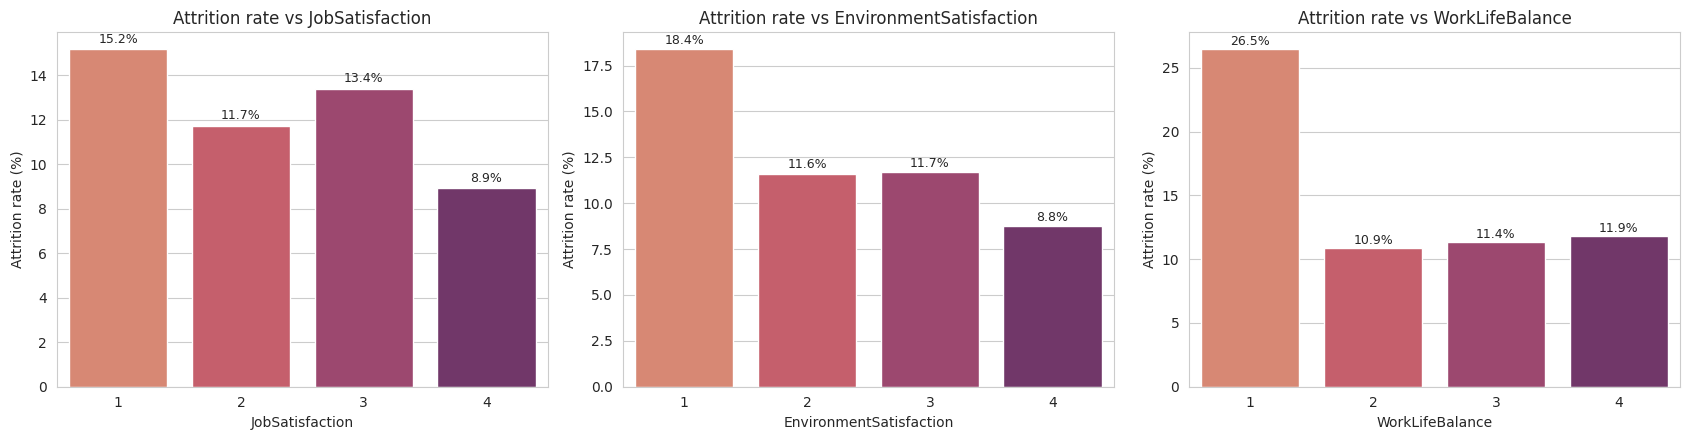

In [ ]:
# Do the satisfaction surveys actually predict anything?
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, col in zip(axes, ["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance"]):
    rate = df.groupby(col)["Attrition"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="flare")
    ax.set_title(f"Attrition rate vs {col}")
    ax.set_ylabel("Attrition rate (%)")
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

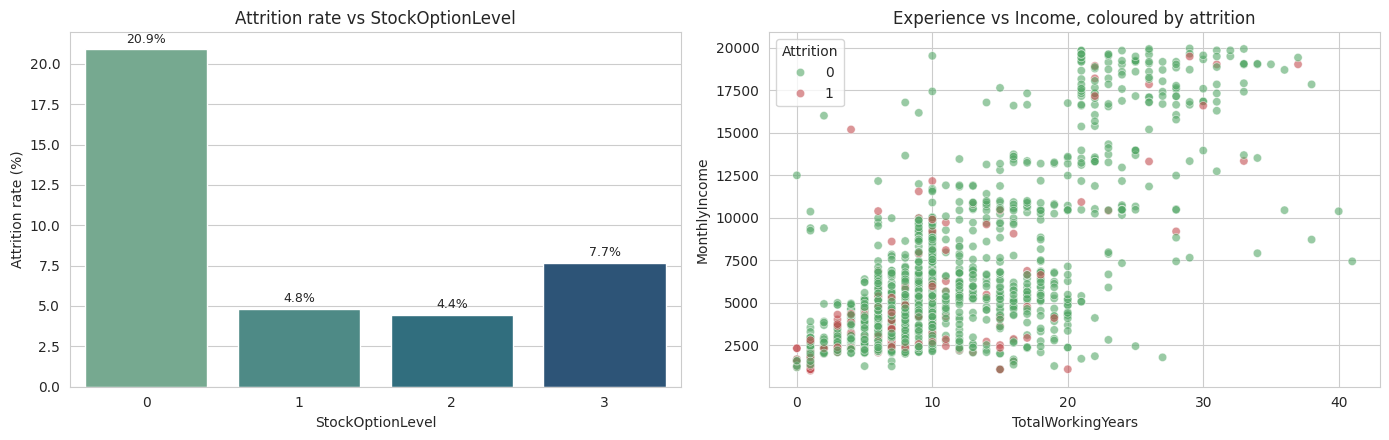

In [ ]:
# Stock options turned out to be one of the strongest single signals, so it gets its own plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

rate = df.groupby("StockOptionLevel")["Attrition"].mean() * 100
sns.barplot(x=rate.index, y=rate.values, ax=axes[0], palette="crest")
axes[0].set_title("Attrition rate vs StockOptionLevel")
axes[0].set_ylabel("Attrition rate (%)")
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)

sns.scatterplot(data=df, x="TotalWorkingYears", y="MonthlyIncome",
                hue="Attrition", alpha=0.6, palette={0: "#55A868", 1: "#C44E52"}, ax=axes[1])
axes[1].set_title("Experience vs Income, coloured by attrition")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("KEY RELATIONSHIPS FOUND DURING EDA")
print("=" * 70)

print("\n1. OVERTIME is the clearest single warning sign")
print(df.groupby("OverTime")["Attrition"].mean().mul(100).round(2).to_string())
print("   Employees doing overtime leave at roughly 2.5x the rate of those who do not.")

print("\n2. MONEY matters a lot")
print(df.groupby("Attrition")["MonthlyIncome"].median().to_string())
print("   The median income of leavers is far below that of the people who stayed.")

print("\n3. STOCK OPTIONS lock people in")
print(df.groupby("StockOptionLevel")["Attrition"].mean().mul(100).round(2).to_string())
print("   Level 0 employees leave about 4x more than employees holding any options.")

print("\n4. YOUNGER and NEWER employees are the flight risk")
print(df.groupby("Attrition")[["Age", "YearsAtCompany", "TotalWorkingYears"]].median().to_string())

print("\n5. ROLE matters")
print(role_rate.head(3).round(2).to_string())
print("   Sales Representatives leave far more than any other role.")

print("\n6. SINGLE employees leave more than married or divorced ones")
print(df.groupby("MaritalStatus")["Attrition"].mean().mul(100).round(2).to_string())
print("=" * 70)

KEY RELATIONSHIPS FOUND DURING EDA

1. OVERTIME is the clearest single warning sign
OverTime
No      8.77
Yes    22.00
   Employees doing overtime leave at roughly 2.5x the rate of those who do not.

2. MONEY matters a lot
Attrition
0    5094.0
1    2921.5
   The median income of leavers is far below that of the people who stayed.

3. STOCK OPTIONS lock people in
StockOptionLevel
0    20.90
1     4.83
2     4.44
3     7.69
   Level 0 employees leave about 4x more than employees holding any options.

4. YOUNGER and NEWER employees are the flight risk
            Age  YearsAtCompany  TotalWorkingYears
Attrition                                         
0          36.0             5.0               10.0
1          31.0             3.0                7.0

5. ROLE matters
JobRole
Sales Representative     33.77
Human Resources          20.59
Laboratory Technician    18.26
   Sales Representatives leave far more than any other role.

6. SINGLE employees leave more than married or divorced ones

---
# 3. Dataset Pre-processing
---

Each fault found in the dataset is discussed **one at a time**: first the problem, then
the solution applied to that problem, and only afterwards do we move on to the next one.

In [ ]:
# Small helper so every problem and its solution is printed in its own clearly separated box.
def print_box(title, body):
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)
    print(body.strip("\n"))
    print("=" * 78 + "\n")

# Work on a copy so the original df stays available for reference
data = df.copy()
print("Shape before pre-processing:", data.shape)

Shape before pre-processing: (1677, 35)


## Problem 1 — Useless columns (identifiers and constants)


#

PROBLEM 1: COLUMNS THAT CARRY NO INFORMATION
==============================================================================
Four columns cannot help any model:

  id             a row number. It is unique for every employee, so a model could
                 memorise it instead of learning a real pattern.
  EmployeeCount  the value is 1 in all 1677 rows.
  StandardHours  the value is 80 in all 1677 rows.
  Over18         the value is 'Y' in all 1677 rows.

A column with the same value everywhere has zero variance. It cannot separate a
leaver from a stayer, because both groups have the identical value. It only adds
noise, extra memory and extra computation.

SOLUTION 1: DELETE THOSE COLUMNS
==============================================================================
Applied technique -> column deletion (not row deletion).

We delete columns and not rows here, because the problem affects an entire column
for every row. Dropping rows would throw away 1677 perfectly good employee records
to fix a column-level issue.

Dropping: ['id', 'EmployeeCount', 'StandardHours', 'Over18']
==============================================================================



In [ ]:
drop_cols = ["id", "EmployeeCount", "StandardHours", "Over18"]
f"Dropping: {drop_cols}"
data = data.drop(columns=drop_cols)
print("Shape after Problem 1:", data.shape)

Shape after Problem 1: (1677, 31)


## Problem 2 — Invalid / impossible values behaving as hidden missing data

"PROBLEM 2: INVALID VALUES HIDING AS NORMAL NUMBERS",

df.isnull().sum() reported ZERO missing cells, so at first glance the dataset looks
perfectly clean. It is not. Section 2.5 showed values that are impossible:

  Education         = 15   but the survey scale only goes from 1 to 5;

  JobLevel          = 7    but job levels only go from 1 to 5;

  DailyRate         = 3921 but the documented maximum is 1499;
  
  TotalWorkingYears > Age  which is impossible for a real person;

These are data entry errors. They are worse than a blank cell, because pandas treats
them as valid numbers. They drag the mean and the standard deviation upwards, and
after scaling they become extreme values that confuse distance based models like KNN.



SOLUTION 2: CONVERT THEM TO NaN, THEN IMPUTE WITH THE MEDIAN",

Applied technique -> mark as missing, then impute (NOT delete the rows).

Step 1: turn every impossible value into NaN, so it is honestly labelled as missing.
Step 2: fill those NaN values with the MEDIAN of the column.

Why impute instead of deleting the rows?
Only a handful of rows are affected, but the minority class (employees who left) has
just 200 rows in total. Deleting rows from such a small dataset wastes information we
cannot afford to lose.



Why the median and not the mean?
The mean is dragged around by the very outliers we are fixing. The median is the
middle value, so it is not affected by extremes and it lands on a realistic value that
already exists on the survey scale.


In [ ]:
# Step 1: flag the impossible values as missing
data.loc[(data["Education"] < 1) | (data["Education"] > 5), "Education"] = np.nan
data.loc[(data["JobLevel"] < 1) | (data["JobLevel"] > 5), "JobLevel"] = np.nan
data.loc[data["DailyRate"] > 1499, "DailyRate"] = np.nan
data.loc[data["TotalWorkingYears"] > data["Age"], "TotalWorkingYears"] = np.nan

print("Missing values created after flagging the invalid entries:")
print(data.isnull().sum()[data.isnull().sum() > 0].to_string())

# Step 2: impute with the median
print("\nImputing:")
for col in ["Education", "JobLevel", "DailyRate", "TotalWorkingYears"]:
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)
    print(f"  {col:<20} filled with median = {median_value}")

# These three were whole numbers before, keep them that way
for col in ["Education", "JobLevel", "TotalWorkingYears"]:
    data[col] = data[col].astype(int)

print("\nRemaining missing values in the whole dataset:", data.isnull().sum().sum())

Missing values created after flagging the invalid entries:
DailyRate            1
Education            1
JobLevel             1
TotalWorkingYears    1

Imputing:
  Education            filled with median = 3.0
  JobLevel             filled with median = 2.0
  DailyRate            filled with median = 890.0
  TotalWorkingYears    filled with median = 9.0

Remaining missing values in the whole dataset: 0


In [ ]:
# One logical error is still left over: a few employees show more years at this company than years worked in total, which cannot happen. We cap them instead of deleting them.

n_illogical = (data["YearsAtCompany"] > data["TotalWorkingYears"]).sum()
mask = data["YearsAtCompany"] > data["TotalWorkingYears"]
data.loc[mask, "YearsAtCompany"] = data.loc[mask, "TotalWorkingYears"]

print(f"Fixed {n_illogical} rows where YearsAtCompany was larger than TotalWorkingYears.")
print("Rows still illogical:", (data["YearsAtCompany"] > data["TotalWorkingYears"]).sum())
print("Shape after Problem 2:", data.shape)

Fixed 3 rows where YearsAtCompany was larger than TotalWorkingYears.
Rows still illogical: 0
Shape after Problem 2: (1677, 31)


## Problem 3 — Categorical (text) values




PROBLEM 3: CATEGORICAL TEXT VALUES",
text columns are still left in the data after dropping Over18:

BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime

Scikit-learn models cannot do arithmetic on the string "Sales Executive". KNN needs to
compute a distance, Logistic Regression needs to multiply by a weight, and the Neural
Network needs matrix multiplication. Feeding text straight in raises a ValueError.


SOLUTION 3: ENCODE, BUT USE A DIFFERENT METHOD PER COLUMN TYPE",

One single encoder for every column would be wrong. The right method depends on
whether the categories have a natural order.

(a) BINARY columns -> map directly to 0 and 1:
    Gender   : Male = 1, Female = 0
    OverTime : Yes = 1,  No = 0
    Only two options exist, so one column of 0s and 1s captures everything.

(b) ORDINAL column -> ordered integers:
    BusinessTravel : Non-Travel = 0, Travel_Rarely = 1, Travel_Frequently = 2
    Here the order is real. Travelling frequently genuinely is "more travel" than
    travelling rarely, so the numbers 0 < 1 < 2 carry true meaning.

(c) NOMINAL columns -> One-Hot Encoding:
    Department, EducationField, JobRole, MaritalStatus
    These have NO natural order. If we labelled JobRole as 0..8, the model would
    wrongly believe that Manager (8) is "eight times" Sales Executive (1), and that
    the average of two roles is a third role. One-Hot creates a separate 0/1 column
    per category so no fake ordering is invented.

   
    We use drop_first=True. With k categories, k-1 columns already describe the data
    completely, and dropping one avoids the dummy variable trap, where the extra
    column is perfectly predictable from the others and destabilises linear models.



In [ ]:
print_box(
    "PROBLEM 3: CATEGORICAL TEXT VALUES",
    f"""
{len(categorical_features) - 1} text columns are still left in the data after dropping Over18:

  BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime

Scikit-learn models cannot do arithmetic on the string "Sales Executive". KNN needs to
compute a distance, Logistic Regression needs to multiply by a weight, and the Neural
Network needs matrix multiplication. Feeding text straight in raises a ValueError.
"""
)



# (a) binary columns
binary_map = {
    "Gender":   {"Male": 1, "Female": 0},
    "OverTime": {"Yes": 1,  "No": 0},
}
for col, mapping in binary_map.items():
    data[col] = data[col].map(mapping)
    print(f"Binary encoded : {col} -> {mapping}")

# (b) ordinal column
travel_map = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
data["BusinessTravel"] = data["BusinessTravel"].map(travel_map)
print(f"Ordinal encoded: BusinessTravel -> {travel_map}")

# (c) nominal columns
nominal_cols = ["Department", "EducationField", "JobRole", "MaritalStatus"]
shape_before = data.shape
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=int)

print(f"\nOne-Hot encoded: {nominal_cols}")
print(f"Shape went from {shape_before} to {data.shape}")
print("Text columns remaining:", data.select_dtypes(include="object").shape[1])
data.head()


PROBLEM 3: CATEGORICAL TEXT VALUES
7 text columns are still left in the data after dropping Over18:

  BusinessTravel, Department, EducationField, Gender, JobRole, MaritalStatus, OverTime

Scikit-learn models cannot do arithmetic on the string "Sales Executive". KNN needs to
compute a distance, Logistic Regression needs to multiply by a weight, and the Neural
Network needs matrix multiplication. Feeding text straight in raises a ValueError.

Binary encoded : Gender -> {'Male': 1, 'Female': 0}
Binary encoded : OverTime -> {'Yes': 1, 'No': 0}
Ordinal encoded: BusinessTravel -> {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}

One-Hot encoded: ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
Shape went from (1677, 31) to (1677, 44)
Text columns remaining: 0


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,36,2,599.0,24,3,4,1,42,3,1,...,0,1,0,0,0,0,0,0,1,0
1,35,1,921.0,8,3,1,1,46,3,1,...,0,0,0,0,0,0,0,1,1,0
2,32,1,718.0,26,3,3,1,80,3,2,...,0,0,0,0,0,0,1,0,0,0
3,38,1,1488.0,2,3,3,0,40,3,2,...,0,0,0,0,0,0,0,0,1,0
4,50,1,1017.0,5,4,2,0,37,3,5,...,0,0,1,0,0,0,0,0,0,1


## Problem 4 — Features are on wildly different scales

***The Problem:*** Different Scales Confuse ModelsColumns like MonthlyRate go up to tens of thousands, while JobSatisfaction only goes from 1 to 4.When numbers are this different, models break:KNN only looks at the big numbers (salary) and completely ignores the small numbers (satisfaction).Neural Networks & Logistic Regression slow down, struggle to calculate, and fail to find the best solution.(Note: Decision Trees do not care about scales, but scaling does not hurt them).


***The Solution:*** Standard Scaling (StandardScaler): We use StandardScaler to give all columns an equal playing field. It transforms every column to have an average (mean) of 0 and a spread (standard deviation) of 1.Why not Min-Max (0 to 1) scaling?Our data has heavy outliers (like extreme salaries). Min-Max would squash all normal salaries into a tiny, useless cluster. Standard Scaling handles outliers much better and keeps the data spread realistic.
it is done in section 4.

***FYI:*** Scale After the Split: we must split your data into Train and Test sets before scaling.Only calculate the scaler's settings (mean and standard deviation) using the Training set. If we include the Test set here, information from the future leaks into the model (Data Leakage), which ruins the honesty of your final test score.

In [ ]:
print("=" * 78)
print("PRE-PROCESSING SUMMARY")
print("=" * 78)
print(f"Original shape                    : {df.shape}")
print(f"Shape after pre-processing        : {data.shape}")
print(f"Columns removed (useless)         : 4")
print(f"Invalid values fixed by imputation: 4")
print(f"Illogical rows capped             : {n_illogical}")
print(f"Categorical columns encoded       : 7")
print(f"Missing values remaining          : {data.isnull().sum().sum()}")
print(f"Non-numeric columns remaining     : {data.select_dtypes(include='object').shape[1]}")
print("Feature scaling                   : done in Section 4, after the split")
print("=" * 78)

data.info()

PRE-PROCESSING SUMMARY
Original shape                    : (1677, 35)
Shape after pre-processing        : (1677, 44)
Columns removed (useless)         : 4
Invalid values fixed by imputation: 4
Illogical rows capped             : 3
Categorical columns encoded       : 7
Missing values remaining          : 0
Non-numeric columns remaining     : 0
Feature scaling                   : done in Section 4, after the split
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1677 entries, 0 to 1676
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1677 non-null   int64  
 1   BusinessTravel                     1677 non-null   int64  
 2   DailyRate                          1677 non-null   float64
 3   DistanceFromHome                   1677 non-null   int64  
 4   Education                          1677 non-null   int64  
 5   EnvironmentSatisfaction 

---
# 4. Dataset Splitting
---

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the input features (X) from the output feature (y)
X = data.drop(columns=["Attrition"])
y = data["Attrition"]

print("X (input features):", X.shape)
print("y (target)        :", y.shape)

X (input features): (1677, 43)
y (target)        : (1677,)


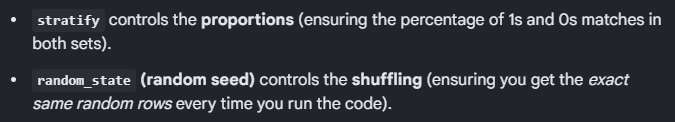

In [ ]:
# 80% train / 20% test, using a STRATIFIED split.
#
# Stratified is essential here, not optional. The minority class has only 200 rows in
# total. A plain random split could easily hand the test set a very different class
# ratio than the training set, which would make the test scores unreliable.
# stratify=y forces both sets to keep the same 88:12 proportion as the original data.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\nClass balance kept identical by stratification:")
print("Full dataset :", dict(y.value_counts(normalize=True).round(4)))
print("Train set    :", dict(y_train.value_counts(normalize=True).round(4)))
print("Test set     :", dict(y_test.value_counts(normalize=True).round(4)))

Training set : 1341 rows (80%)
Test set     : 336 rows (20%)

Class balance kept identical by stratification:
Full dataset : {0: np.float64(0.8807), 1: np.float64(0.1193)}
Train set    : {0: np.float64(0.8807), 1: np.float64(0.1193)}
Test set     : {0: np.float64(0.881), 1: np.float64(0.119)}


In [ ]:
from sklearn.preprocessing import StandardScaler

# Now we apply the scaling promised in Problem 4.
# fit_transform on train (learns mean and std), transform only on test (reuses them).

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print("Scaling done. A few columns before and after:\n")
print("BEFORE:")
print(X_train[["Age", "MonthlyIncome", "MonthlyRate"]].describe().T[["mean", "std", "min", "max"]].round(2))
print("\nAFTER:")
print(X_train_scaled[["Age", "MonthlyIncome", "MonthlyRate"]].describe().T[["mean", "std", "min", "max"]].round(2))

Scaling done. A few columns before and after:

BEFORE:
                   mean      std     min      max
Age               36.08     8.59    18.0     60.0
MonthlyIncome   6216.41  4521.39  1010.0  19973.0
MonthlyRate    14869.66  7160.08   636.0  26999.0

AFTER:
               mean  std   min   max
Age             0.0  1.0 -2.11  2.79
MonthlyIncome  -0.0  1.0 -1.15  3.04
MonthlyRate     0.0  1.0 -1.99  1.69


**RANDOM OVERSAMPLING of the minority class, applied to the TRAINING SET**
----------------------------------------------------------------------------


*  Splits the data into two separate buckets: employees who stayed and employees who left.
*  Clones the rows of the smaller "left" bucket by randomly copying them over and over.
*   Matches the group sizes until the number of "left" records equals the number of "stayed" records.
*   Shuffles both groups back together into one balanced dataset with a perfect 50:50 mix.









In [ ]:
from sklearn.utils import resample

# Section 2.9 showed the training data is 88:12 imbalanced. If we train on it as is,
# the models learn that always guessing "stayed" is a winning strategy.
#
# Fix: RANDOM OVERSAMPLING of the minority class, applied to the TRAINING SET ONLY.
# The test set is deliberately left untouched so it still reflects reality.

def balance_by_oversampling(X_part, y_part, seed=RANDOM_STATE):
    temp = X_part.copy()
    temp["Attrition"] = y_part.values

    majority = temp[temp["Attrition"] == 0]
    minority = temp[temp["Attrition"] == 1]

    # duplicate minority rows (with replacement) until both classes match in size
    minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=seed)

    balanced = pd.concat([majority, minority_up]).sample(frac=1, random_state=seed).reset_index(drop=True)
    return balanced.drop(columns=["Attrition"]), balanced["Attrition"]


X_train_bal, y_train_bal = balance_by_oversampling(X_train_scaled, y_train)

print("Training set BEFORE balancing:", dict(y_train.value_counts()))
print("Training set AFTER  balancing:", dict(y_train_bal.value_counts()))
print("\nTest set left untouched      :", dict(y_test.value_counts()))
print("\nBalanced training shape:", X_train_bal.shape)

Training set BEFORE balancing: {0: np.int64(1181), 1: np.int64(160)}
Training set AFTER  balancing: {0: np.int64(1181), 1: np.int64(1181)}

Test set left untouched      : {0: np.int64(296), 1: np.int64(40)}

Balanced training shape: (2362, 43)


---
# 5. Model Training & Testing
---

Three supervised classifiers are trained, then K-Means is applied to the same data as an
unsupervised problem.

| Model | Type |
|---|---|
| Logistic Regression | linear |
| Naive Bayes | probabilistic |
| Neural Network (MLP) | deep learning |

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

# Every model is stored here so Section 6 can compare them side by side.
results = {}


def train_and_evaluate(name, model, X_tr=None, y_tr=None):
    """Fit a model on the balanced training data and score it on the untouched test set."""
    X_tr = X_train_bal if X_tr is None else X_tr
    y_tr = y_train_bal if y_tr is None else y_tr

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1, needed for ROC

    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "auc":       roc_auc_score(y_test, y_prob),
        "cm":        confusion_matrix(y_test, y_pred),
    }

    r = results[name]
    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)
    print(f"Accuracy  : {r['accuracy']:.4f}")
    print(f"Precision : {r['precision']:.4f}")
    print(f"Recall    : {r['recall']:.4f}")
    print(f"F1 Score  : {r['f1']:.4f}")
    print(f"AUC Score : {r['auc']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["Stayed (0)", "Left (1)"], zero_division=0))
    print("Confusion matrix:")
    print(r["cm"])
    print("=" * 70)
    return model

print("Helper ready.")

Helper ready.


## 5.1 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# max_iter is raised from the default 100 because with 43 features the solver
# needs more passes to converge.

lr_model = train_and_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
)

  Logistic Regression
Accuracy  : 0.7560
Precision : 0.2717
Recall    : 0.6250
F1 Score  : 0.3788
AUC Score : 0.7606

Classification report:
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.77      0.85       296
    Left (1)       0.27      0.62      0.38        40

    accuracy                           0.76       336
   macro avg       0.61      0.70      0.61       336
weighted avg       0.86      0.76      0.79       336

Confusion matrix:
[[229  67]
 [ 15  25]]


**Step 1: Extract and Pair the final optimized Weights**

coefs = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()

lr_model.coef_[0]: When the model trains, it calculates a numerical score (weight) for every single feature. This grabs that list of numbers.

index=X.columns: It matches each number to its real column name (e.g., matching -0.75 to StockOptionLevel).

.sort_values(): It sorts everything from the lowest negative number to the highest positive number.

**Step 2: Grab the Top 10 on Each Side**
top_both = pd.concat([coefs.head(10), coefs.tail(10)])


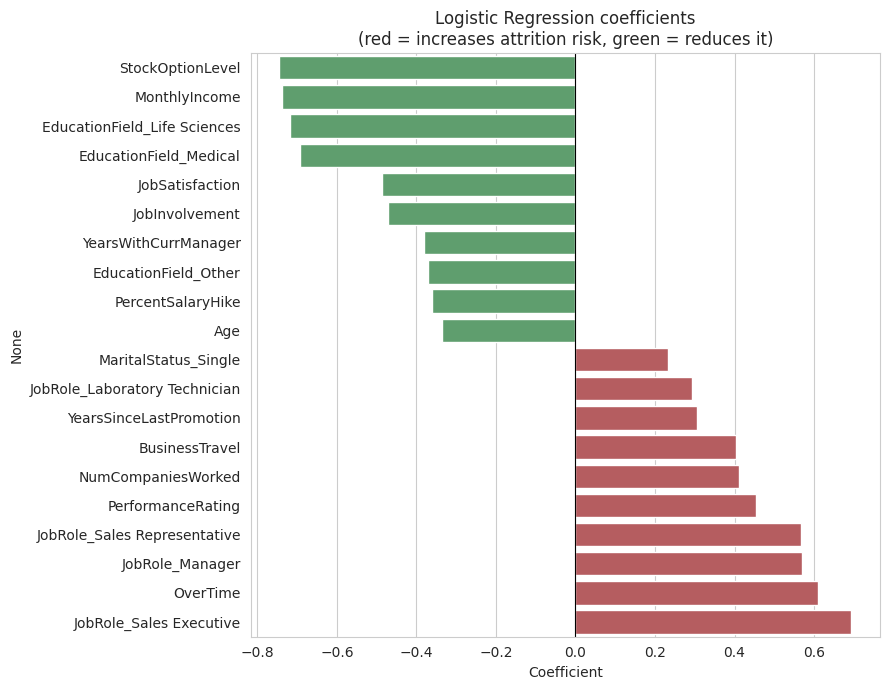

Strongest RISK factors:
YearsSinceLastPromotion         0.305
BusinessTravel                  0.403
NumCompaniesWorked              0.411
PerformanceRating               0.455
JobRole_Sales Representative    0.566
JobRole_Manager                 0.571
OverTime                        0.610
JobRole_Sales Executive         0.694

Strongest RETENTION factors:
StockOptionLevel               -0.745
MonthlyIncome                  -0.739
EducationField_Life Sciences   -0.717
EducationField_Medical         -0.694
JobSatisfaction                -0.488
JobInvolvement                 -0.473
YearsWithCurrManager           -0.381
EducationField_Other           -0.372


In [ ]:
# Logistic Regression gives a weight per feature.
# Positive weight -> pushes the prediction towards "left", negative -> towards "stayed".

coefs = pd.Series(lr_model.coef_[0], index=X.columns).sort_values()
top_both = pd.concat([coefs.head(10), coefs.tail(10)])

plt.figure(figsize=(9, 7))
colors = ["#55A868" if v < 0 else "#C44E52" for v in top_both.values]
sns.barplot(x=top_both.values, y=top_both.index, palette=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients\n(red = increases attrition risk, green = reduces it)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

print("Strongest RISK factors:")
print(coefs.tail(8).round(3).to_string())
print("\nStrongest RETENTION factors:")
print(coefs.head(8).round(3).to_string())

## 5.2 Naive Bayes


**GaussianNB is used here because most of your variables are continuous numbers. However, Naive Bayes assumes a "naive" rule: it thinks every feature is completely independent of the others. In real-world dataset, this assumption is false because columns like JobLevel and MonthlyIncome are highly linked (91% correlation), meaning the model will double-count that overlapping information when making its predictions.

Gaussian Naive Bayes (GaussianNB) is chosen here because it handles continuous numeric columns**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = train_and_evaluate("Naive Bayes", GaussianNB())

  Naive Bayes
Accuracy  : 0.5685
Precision : 0.1818
Recall    : 0.7500
F1 Score  : 0.2927
AUC Score : 0.6990

Classification report:
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.54      0.69       296
    Left (1)       0.18      0.75      0.29        40

    accuracy                           0.57       336
   macro avg       0.56      0.65      0.49       336
weighted avg       0.85      0.57      0.64       336

Confusion matrix:
[[161 135]
 [ 10  30]]


## 5.3 Neural Network (Multi-Layer Perceptron)

In [ ]:
from sklearn.neural_network import MLPClassifier

# Architecture: 43 inputs -> 64 neurons -> 32 neurons -> 1 output
#   relu            : standard hidden layer activation, avoids vanishing gradients
#   adam            : adaptive optimiser, works well without manual tuning
#   alpha           : L2 regularisation to fight overfitting
#   early_stopping  : holds back 15% of training data and stops when it stops improving

nn_model = train_and_evaluate(
    "Neural Network",
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=15,
        validation_fraction=0.15,
        random_state=RANDOM_STATE
    )
)

  Neural Network
Accuracy  : 0.8452
Precision : 0.3500
Recall    : 0.3500
F1 Score  : 0.3500
AUC Score : 0.7048

Classification report:
              precision    recall  f1-score   support

  Stayed (0)       0.91      0.91      0.91       296
    Left (1)       0.35      0.35      0.35        40

    accuracy                           0.85       336
   macro avg       0.63      0.63      0.63       336
weighted avg       0.85      0.85      0.85       336

Confusion matrix:
[[270  26]
 [ 26  14]]


Network architecture:
  Input features   : 43
  Hidden layer 1   : 64 neurons (relu)
  Hidden layer 2   : 32 neurons (relu)
  Output           : 1 neuron (sigmoid)
  Epochs actually run: 37 (early stopping was active)


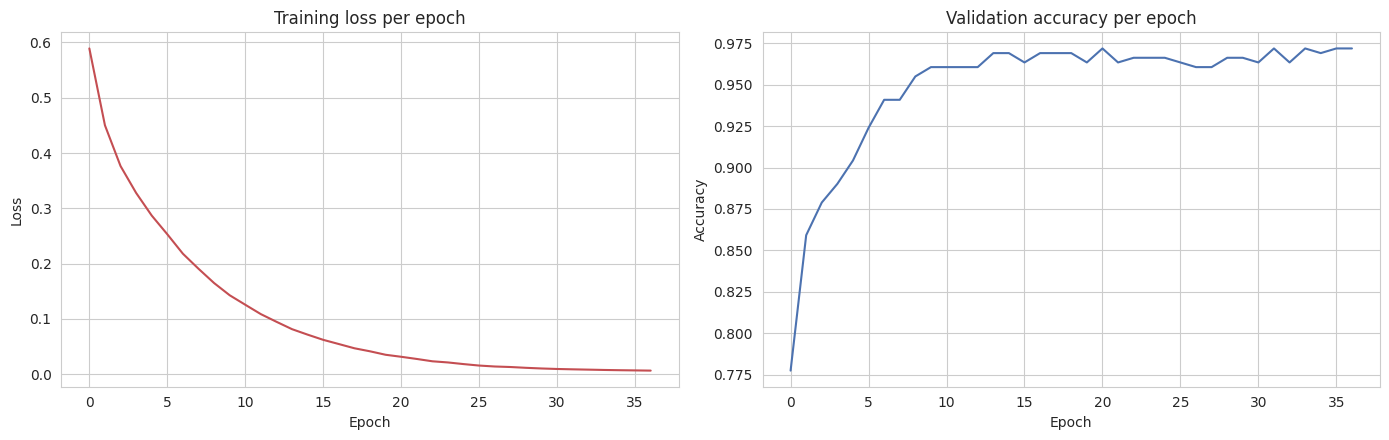

In [ ]:
# Network summary and training curves
print("Network architecture:")
print(f"  Input features   : {X_train_bal.shape[1]}")
for i, layer in enumerate(nn_model.hidden_layer_sizes):
    print(f"  Hidden layer {i+1}   : {layer} neurons (relu)")
print(f"  Output           : 1 neuron (sigmoid)")
print(f"  Epochs actually run: {nn_model.n_iter_} (early stopping was active)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(nn_model.loss_curve_, color="#C44E52")
axes[0].set_title("Training loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(nn_model.validation_scores_, color="#4C72B0")
axes[1].set_title("Validation accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 5.4 Unsupervised approach — K-Means Clustering

Here we deliberately **throw away the labels** and ask a different question: without
being told who left, does K-Means find natural groups inside the employee data, and do
those groups happen to line up with attrition?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# For clustering we use the whole dataset without the target column,
# scaled, because K-Means is a distance based algorithm just like KNN.
X_unsupervised = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

print("Data used for clustering:", X_unsupervised.shape, "(target column removed)")

Data used for clustering: (1677, 43) (target column removed)


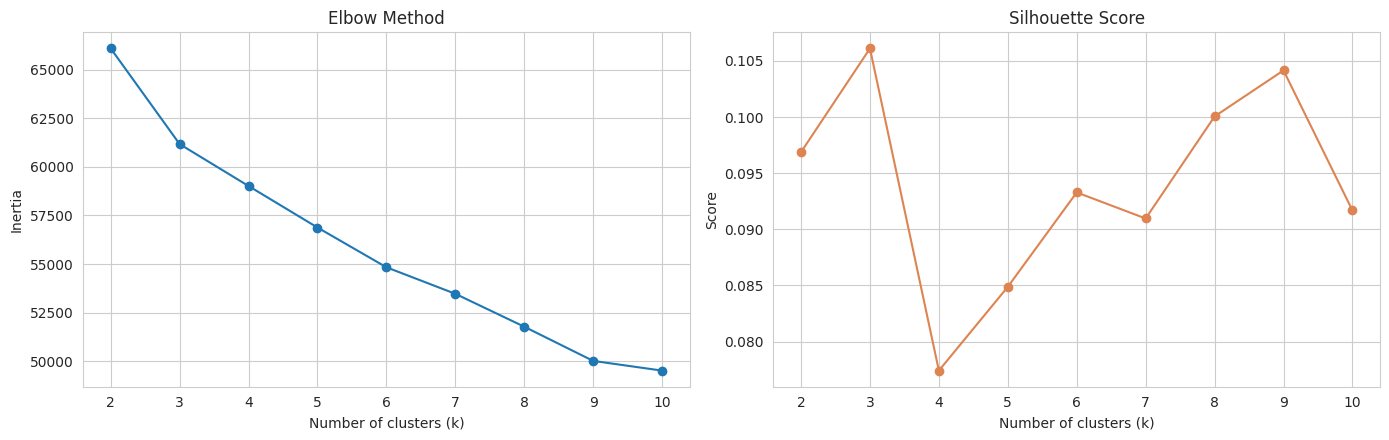

  k =  2  silhouette = 0.0969
  k =  3  silhouette = 0.1061
  k =  4  silhouette = 0.0774
  k =  5  silhouette = 0.0849
  k =  6  silhouette = 0.0933
  k =  7  silhouette = 0.0910
  k =  8  silhouette = 0.1001
  k =  9  silhouette = 0.1042
  k = 10  silhouette = 0.0917


In [ ]:
# How many clusters should we ask for? Two standard checks:
#   Elbow method   - where does adding another cluster stop reducing inertia much
#   Silhouette     - how well separated the clusters are (higher is better)

inertia_values, silhouette_values = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_unsupervised)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_unsupervised, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(k_range), inertia_values, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_values):
    print(f"  k = {k:2d}  silhouette = {s:.4f}")

Cluster sizes: {0: np.int64(646), 1: np.int64(1031)}
Silhouette score: 0.0969


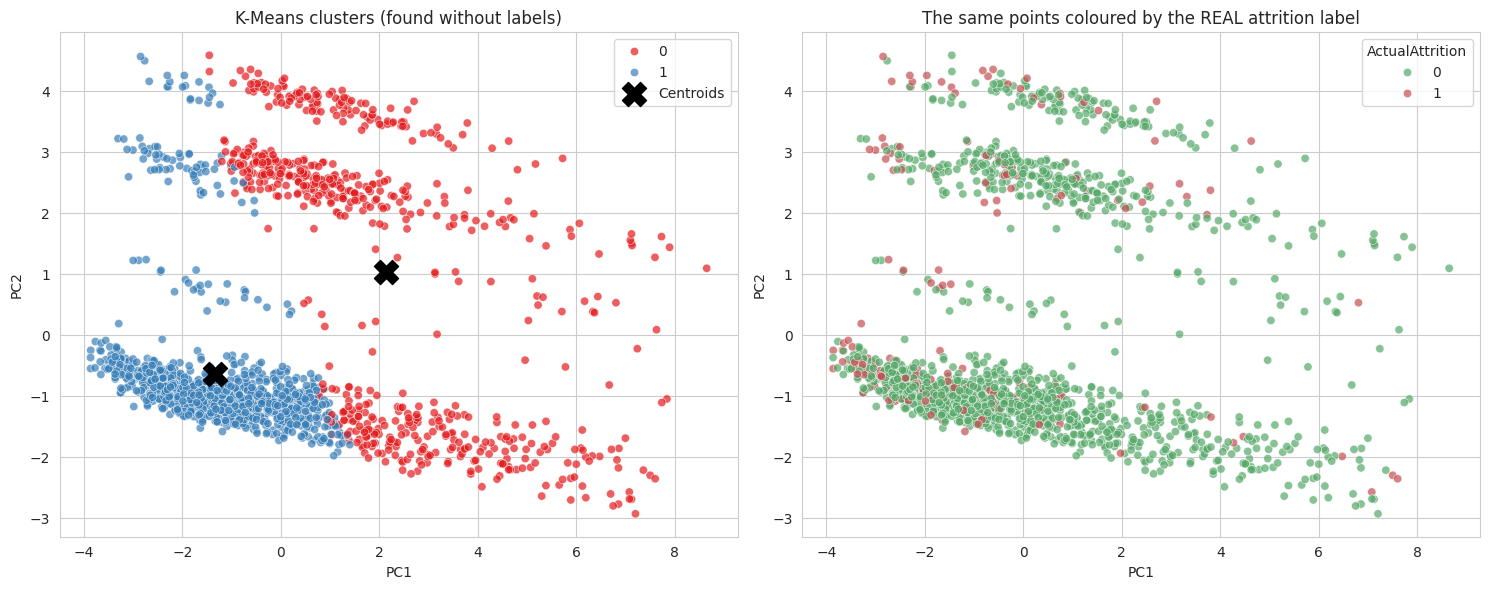


PCA explains 20.6% of the total variance (PC1 12.6%, PC2 8.0%)


In [ ]:
# We fix k = 2 so the clusters can be compared directly against our two real classes.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_unsupervised)

print("Cluster sizes:", dict(pd.Series(cluster_labels).value_counts().sort_index()))
print(f"Silhouette score: {silhouette_score(X_unsupervised, cluster_labels):.4f}")

# 43 dimensions cannot be plotted, so PCA compresses them into 2 for visualisation only.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_unsupervised)

plot_df = pd.DataFrame(components, columns=["PC1", "PC2"])
plot_df["Cluster"] = cluster_labels
plot_df["ActualAttrition"] = y.values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster",
                palette="Set1", alpha=0.7, ax=axes[0])
axes[0].scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
                pca.transform(kmeans.cluster_centers_)[:, 1],
                s=300, c="black", marker="X", label="Centroids")
axes[0].set_title("K-Means clusters (found without labels)")
axes[0].legend()

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="ActualAttrition",
                palette={0: "#55A868", 1: "#C44E52"}, alpha=0.7, ax=axes[1])
axes[1].set_title("The same points coloured by the REAL attrition label")

plt.tight_layout()
plt.show()

print(f"\nPCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of the total variance "
      f"(PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%)")

In [ ]:
# Do the clusters match the real classes?
crosstab = pd.crosstab(cluster_labels, y, rownames=["Cluster"], colnames=["Actual Attrition"])
print("Cluster vs actual attrition:\n")
print(crosstab.to_string())

ari = adjusted_rand_score(y, cluster_labels)
print(f"\nAdjusted Rand Index (1.0 = perfect match, 0.0 = random): {ari:.4f}")

print("\nAttrition rate inside each cluster:")
for c in sorted(set(cluster_labels)):
    rate = y[cluster_labels == c].mean() * 100
    print(f"  Cluster {c}: {sum(cluster_labels == c):4d} employees, {rate:.2f}% left")

Cluster vs actual attrition:

Actual Attrition    0    1
Cluster                   
0                 593   53
1                 884  147

Adjusted Rand Index (1.0 = perfect match, 0.0 = random): -0.0175

Attrition rate inside each cluster:
  Cluster 0:  646 employees, 8.20% left
  Cluster 1: 1031 employees, 14.26% left


In [ ]:
# What actually defines each cluster? Comparing the average employee in each one.
profile_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "JobLevel",
                "YearsAtCompany", "YearsInCurrentRole", "OverTime", "StockOptionLevel"]

profile = X.copy()
profile["Cluster"] = cluster_labels
cluster_profile = profile.groupby("Cluster")[profile_cols].mean().round(2)

print("Average profile of each cluster:\n")
print(cluster_profile.to_string())

print("""
--------------------------------------------------------------------
WHAT K-MEANS ACTUALLY FOUND

K-Means did NOT rediscover attrition. The Adjusted Rand Index is close to
zero, which means the clusters and the real labels are essentially unrelated.

Instead it split the workforce by SENIORITY, which is the strongest source
of variation in the data:

  Cluster 0 = senior staff. Older, much higher income, higher job level,
              many years of experience.
  Cluster 1 = junior staff. Younger, lower paid, lower job level, newer.

This is still a useful result. The junior cluster has a noticeably higher
attrition rate than the senior cluster, so seniority is genuinely linked to
attrition, but it is far from the whole story.

The wider lesson: unsupervised learning finds the structure that dominates
the feature space, not necessarily the structure we happen to be interested
in. Since attrition is a weak, scattered signal in this dataset, K-Means
cannot recover it. This is exactly why the supervised models, which are
explicitly shown the labels, do better at this task.
--------------------------------------------------------------------
""")

Average profile of each cluster:

           Age  MonthlyIncome  TotalWorkingYears  JobLevel  YearsAtCompany  YearsInCurrentRole  OverTime  StockOptionLevel
Cluster                                                                                                                   
0        39.48        9716.39              15.65      2.89           10.24                5.99      0.25              0.75
1        33.88        3990.29               7.58      1.44            4.62                2.99      0.23              0.71

--------------------------------------------------------------------
WHAT K-MEANS ACTUALLY FOUND

K-Means did NOT rediscover attrition. The Adjusted Rand Index is close to
zero, which means the clusters and the real labels are essentially unrelated.

Instead it split the workforce by SENIORITY, which is the strongest source
of variation in the data:

  Cluster 0 = senior staff. Older, much higher income, higher job level,
              many years of experience.
  Clust

---
# 6. Model Selection / Comparison Analysis
---

In [ ]:
# Collecting every metric from every model into one table
comparison = pd.DataFrame({
    name: {
        "Accuracy":  r["accuracy"],
        "Precision": r["precision"],
        "Recall":    r["recall"],
        "F1 Score":  r["f1"],
        "AUC":       r["auc"],
    }
    for name, r in results.items()
}).T

print("=" * 78)
print("ALL MODELS, ALL METRICS")
print("=" * 78)
print(comparison.round(4).to_string())
print("=" * 78)

majority_baseline = (y_test == 0).mean()
print(f"\nMajority-class baseline (predicting 'stayed' for everyone): {majority_baseline:.4f}")
print("Any model must be judged against this number, not against 0.")

ALL MODELS, ALL METRICS
                     Accuracy  Precision  Recall  F1 Score     AUC
Logistic Regression    0.7560     0.2717   0.625    0.3788  0.7606
Naive Bayes            0.5685     0.1818   0.750    0.2927  0.6990
Neural Network         0.8452     0.3500   0.350    0.3500  0.7048

Majority-class baseline (predicting 'stayed' for everyone): 0.8810
Any model must be judged against this number, not against 0.


## 6.1 Accuracy comparison (bar chart)

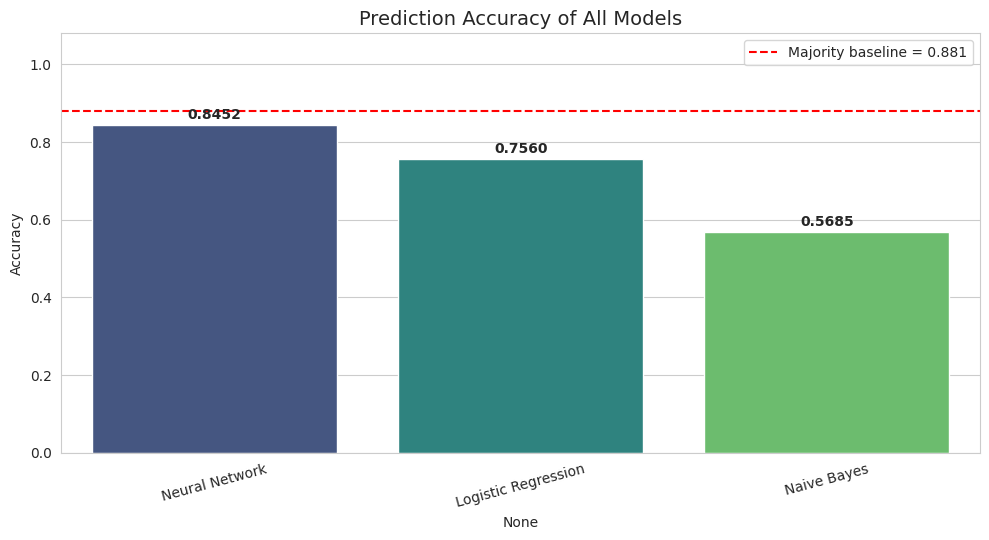

Neural Network         0.8452
Logistic Regression    0.7560
Naive Bayes            0.5685


In [ ]:
plt.figure(figsize=(10, 5.5))
sorted_acc = comparison["Accuracy"].sort_values(ascending=False)

bars = sns.barplot(x=sorted_acc.index, y=sorted_acc.values, palette="viridis")
for i, v in enumerate(sorted_acc.values):
    bars.text(i, v + 0.015, f"{v:.4f}", ha="center", fontweight="bold")

plt.axhline(majority_baseline, color="red", linestyle="--", linewidth=1.5,
            label=f"Majority baseline = {majority_baseline:.3f}")
plt.title("Prediction Accuracy of All Models", fontsize=14)
plt.ylabel("Accuracy")
plt.ylim(0, 1.08)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

print(sorted_acc.round(4).to_string())

## 6.2 Precision and Recall comparison

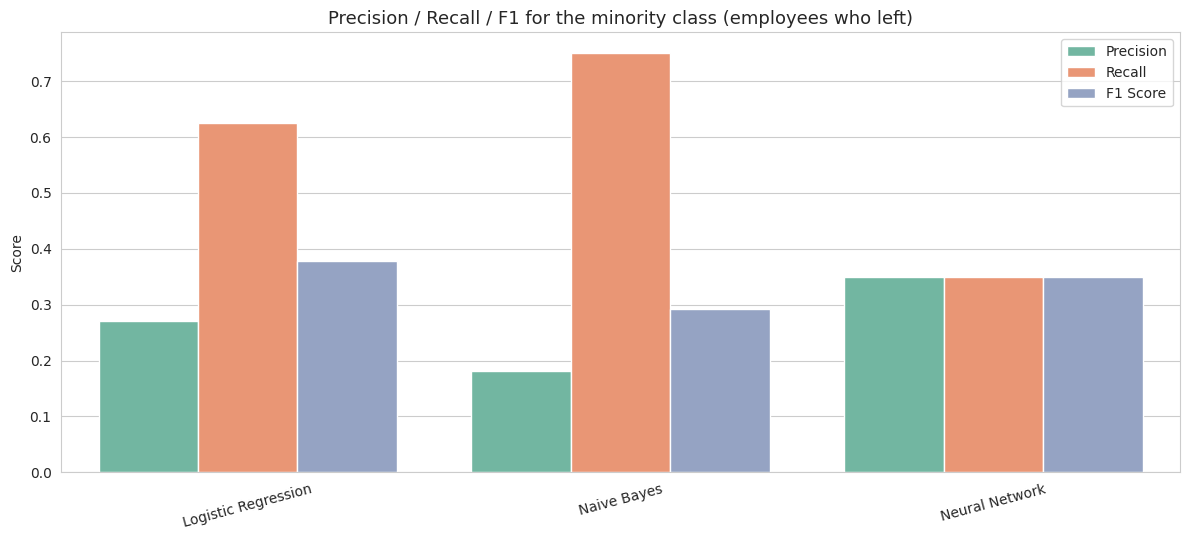

                     Precision  Recall  F1 Score
Logistic Regression     0.2717   0.625    0.3788
Naive Bayes             0.1818   0.750    0.2927
Neural Network          0.3500   0.350    0.3500

How to read these two metrics in this project:

  PRECISION = of all employees the model flagged as leaving, how many really left.
              Low precision means HR wastes retention effort on people who were
              never going to leave.

  RECALL    = of all employees who really left, how many did the model catch.
              Low recall means the model misses the actual leavers, which is the
              expensive failure for a company.

For an attrition problem RECALL usually matters more, because missing a real
leaver costs a full replacement hire, while a false alarm only costs a
conversation.



In [ ]:
melted = comparison[["Precision", "Recall", "F1 Score"]].reset_index().melt(
    id_vars="index", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5.5))
sns.barplot(data=melted, x="index", y="Score", hue="Metric", palette="Set2")
plt.title("Precision / Recall / F1 for the minority class (employees who left)", fontsize=13)
plt.xlabel("")
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()
plt.show()

print(comparison[["Precision", "Recall", "F1 Score"]].round(4).to_string())

print("""
How to read these two metrics in this project:

  PRECISION = of all employees the model flagged as leaving, how many really left.
              Low precision means HR wastes retention effort on people who were
              never going to leave.

  RECALL    = of all employees who really left, how many did the model catch.
              Low recall means the model misses the actual leavers, which is the
              expensive failure for a company.

For an attrition problem RECALL usually matters more, because missing a real
leaver costs a full replacement hire, while a false alarm only costs a
conversation.
""")

## 6.3 Confusion matrices

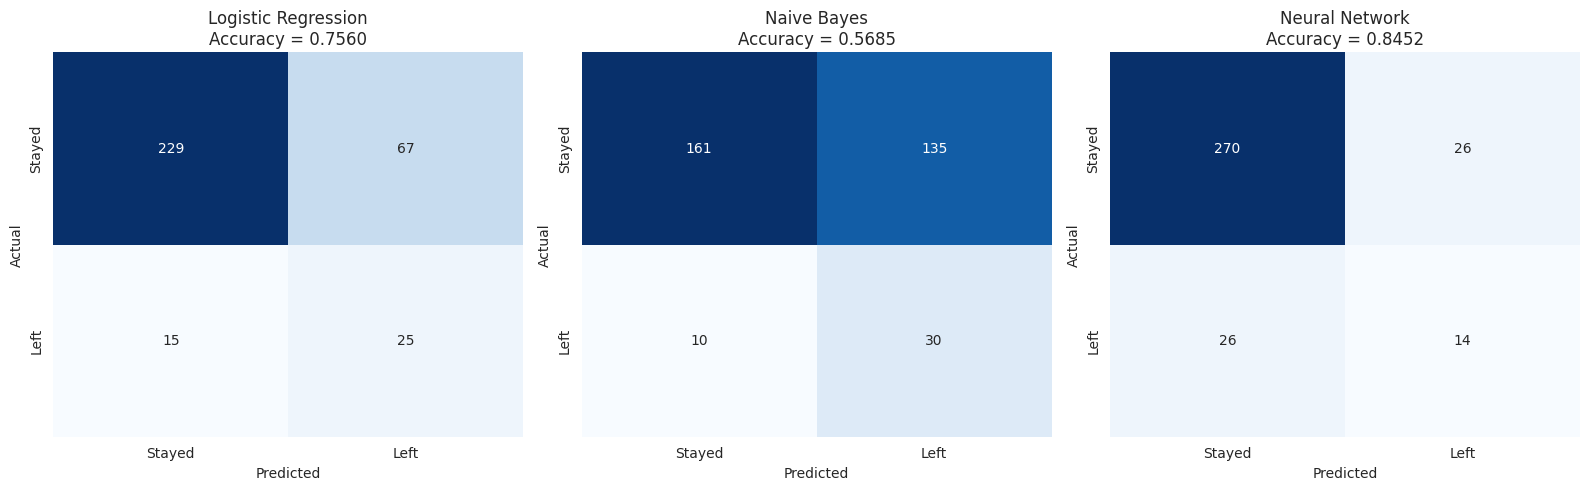

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
    ax.set_title(f"{name}\nAccuracy = {r['accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for j in range(len(results), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# The same confusion matrices written out in words, one model at a time
print("=" * 78)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 78)

for name, r in results.items():
    tn, fp, fn, tp = r["cm"].ravel()
    print(f"\n{name}")
    print("-" * len(name))
    print(f"  True Negatives  (stayed, predicted stayed) : {tn}")
    print(f"  False Positives (stayed, predicted left)   : {fp}   <- false alarms")
    print(f"  False Negatives (left,   predicted stayed) : {fn}   <- MISSED leavers")
    print(f"  True Positives  (left,   predicted left)   : {tp}   <- correctly caught")
    print(f"  Caught {tp} out of {tp + fn} real leavers ({tp/(tp+fn)*100:.1f}%)")

print("\n" + "=" * 78)

CONFUSION MATRIX BREAKDOWN

Logistic Regression
-------------------
  True Negatives  (stayed, predicted stayed) : 229
  False Positives (stayed, predicted left)   : 67   <- false alarms
  False Negatives (left,   predicted stayed) : 15   <- MISSED leavers
  True Positives  (left,   predicted left)   : 25   <- correctly caught
  Caught 25 out of 40 real leavers (62.5%)

Naive Bayes
-----------
  True Negatives  (stayed, predicted stayed) : 161
  False Positives (stayed, predicted left)   : 135   <- false alarms
  False Negatives (left,   predicted stayed) : 10   <- MISSED leavers
  True Positives  (left,   predicted left)   : 30   <- correctly caught
  Caught 30 out of 40 real leavers (75.0%)

Neural Network
--------------
  True Negatives  (stayed, predicted stayed) : 270
  False Positives (stayed, predicted left)   : 26   <- false alarms
  False Negatives (left,   predicted stayed) : 26   <- MISSED leavers
  True Positives  (left,   predicted left)   : 14   <- correctly caught
  Caug

## 6.4 ROC curve and AUC score

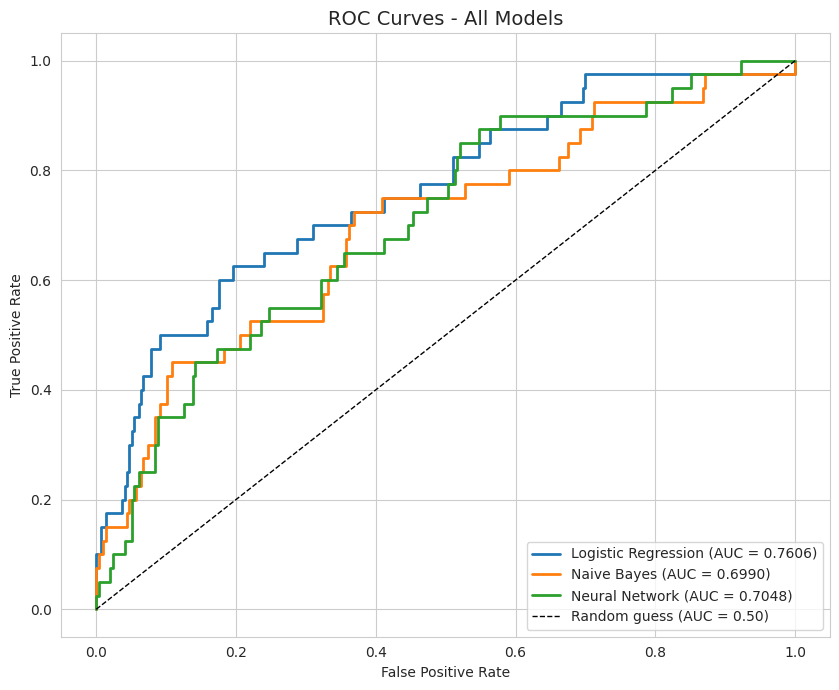

AUC scores (higher is better, 0.5 = random guessing):

Logistic Regression    0.7606
Neural Network         0.7048
Naive Bayes            0.6990

AUC is the fairest single number for an imbalanced problem like this one.
Unlike accuracy, it does not depend on the 0.5 decision threshold and it is not
inflated by the huge majority class. It measures how well the model RANKS a random
leaver above a random stayer.



In [ ]:
plt.figure(figsize=(8.5, 7))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {r['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("AUC scores (higher is better, 0.5 = random guessing):\n")
print(comparison["AUC"].sort_values(ascending=False).round(4).to_string())

print("""
AUC is the fairest single number for an imbalanced problem like this one.
Unlike accuracy, it does not depend on the 0.5 decision threshold and it is not
inflated by the huge majority class. It measures how well the model RANKS a random
leaver above a random stayer.
""")

## 6.5 Full per-model report

In [ ]:
# Every model printed separately with all of its metrics in one place
for name, r in results.items():
    tn, fp, fn, tp = r["cm"].ravel()
    print("\n" + "#" * 78)
    print(f"#  MODEL: {name}")
    print("#" * 78)
    print(f"  Accuracy   : {r['accuracy']:.4f}")
    print(f"  Precision  : {r['precision']:.4f}")
    print(f"  Recall     : {r['recall']:.4f}")
    print(f"  F1 Score   : {r['f1']:.4f}")
    print(f"  AUC Score  : {r['auc']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                    Predicted Stayed   Predicted Left")
    print(f"    Actual Stayed        {tn:5d}            {fp:5d}")
    print(f"    Actual Left          {fn:5d}            {tp:5d}")
    print(f"\n  Detailed report:")
    print(classification_report(y_test, r["y_pred"],
                                target_names=["Stayed (0)", "Left (1)"], zero_division=0))


##############################################################################
#  MODEL: Logistic Regression
##############################################################################
  Accuracy   : 0.7560
  Precision  : 0.2717
  Recall     : 0.6250
  F1 Score   : 0.3788
  AUC Score  : 0.7606

  Confusion Matrix:
                    Predicted Stayed   Predicted Left
    Actual Stayed          229               67
    Actual Left             15               25

  Detailed report:
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.77      0.85       296
    Left (1)       0.27      0.62      0.38        40

    accuracy                           0.76       336
   macro avg       0.61      0.70      0.61       336
weighted avg       0.86      0.76      0.79       336


##############################################################################
#  MODEL: Naive Bayes
##############################################################################
  

## 6.6 Which model wins?

In [ ]:
print("=" * 78)
print("BEST MODEL PER METRIC")
print("=" * 78)
for metric in ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]:
    winner = comparison[metric].idxmax()
    print(f"  Highest {metric:<10}: {winner:<22} ({comparison.loc[winner, metric]:.4f})")

print("\n" + "=" * 78)
print("OVERALL RANKING BY AUC (the most reliable metric for imbalanced data)")
print("=" * 78)
print(comparison.sort_values("AUC", ascending=False).round(4).to_string())

BEST MODEL PER METRIC
  Highest Accuracy  : Neural Network         (0.8452)
  Highest Precision : Neural Network         (0.3500)
  Highest Recall    : Naive Bayes            (0.7500)
  Highest F1 Score  : Logistic Regression    (0.3788)
  Highest AUC       : Logistic Regression    (0.7606)

OVERALL RANKING BY AUC (the most reliable metric for imbalanced data)
                     Accuracy  Precision  Recall  F1 Score     AUC
Logistic Regression    0.7560     0.2717   0.625    0.3788  0.7606
Neural Network         0.8452     0.3500   0.350    0.3500  0.7048
Naive Bayes            0.5685     0.1818   0.750    0.2927  0.6990


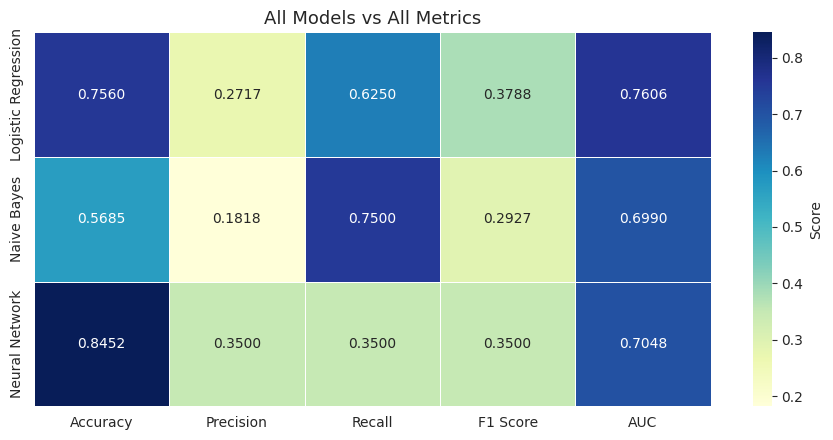

In [ ]:
# Heatmap version of the comparison table
plt.figure(figsize=(9, 4.5))
sns.heatmap(comparison, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Score"})
plt.title("All Models vs All Metrics", fontsize=13)
plt.tight_layout()
plt.show()

#If we ignore the class imbalance?

This experiment is what justifies the oversampling step from Section 4.

true case gular modhe model koyta catch korte parse= recall

TRAINING ON IMBALANCED DATA vs BALANCED DATA
                     Accuracy (imbalanced)  Accuracy (balanced)  Recall (imbalanced)  Recall (balanced)
Logistic Regression                 0.8810               0.7560                  0.2              0.625
Naive Bayes                         0.6726               0.5685                  0.6              0.750
Neural Network                      0.8810               0.8452                  0.1              0.350

Reading this table:

Trained on the raw imbalanced data, the models score HIGHER accuracy, some of them
right at the 0.881 baseline. But look at the recall column: it collapses.
Those models are barely catching any real leavers, they are just predicting "stayed"
almost every time and collecting free accuracy from the 88% majority.

After oversampling, accuracy drops but recall rises sharply. The models are now
actually attempting the task we care about.

This is the accuracy paradox, and it is the single most important thing to
unde

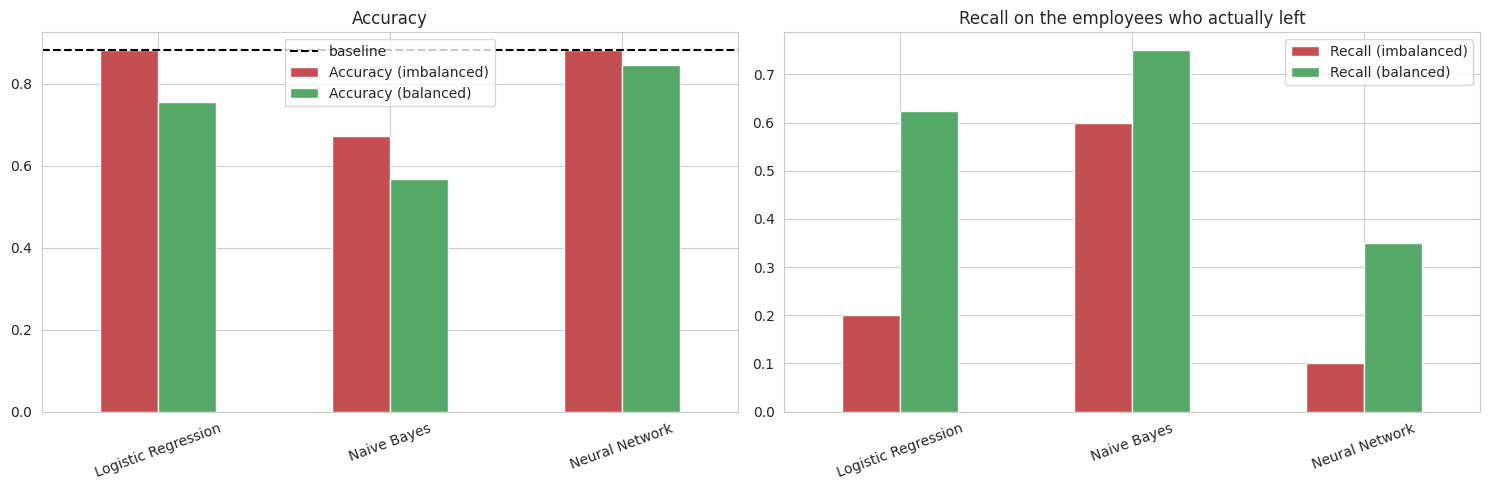

In [ ]:
# Retraining every model on the ORIGINAL imbalanced training data, for comparison only.
from sklearn.base import clone

imbalanced_rows = []

for name, r in results.items():
    m = clone(r["model"])
    m.fit(X_train_scaled, y_train)                     # unbalanced training data
    yp = m.predict(X_test_scaled)
    pr = m.predict_proba(X_test_scaled)[:, 1]
    imbalanced_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yp),
        "Recall": recall_score(y_test, yp, zero_division=0),
        "AUC": roc_auc_score(y_test, pr),
    })

imb_results = pd.DataFrame(imbalanced_rows).set_index("Model")

compare_side = pd.DataFrame({
    "Accuracy (imbalanced)": imb_results["Accuracy"],
    "Accuracy (balanced)":   comparison["Accuracy"],
    "Recall (imbalanced)":   imb_results["Recall"],
    "Recall (balanced)":     comparison["Recall"],
}).round(4)

print("=" * 78)
print("TRAINING ON IMBALANCED DATA vs BALANCED DATA")
print("=" * 78)
print(compare_side.to_string())

print(f"""
Reading this table:

Trained on the raw imbalanced data, the models score HIGHER accuracy, some of them
right at the {majority_baseline:.3f} baseline. But look at the recall column: it collapses.
Those models are barely catching any real leavers, they are just predicting "stayed"
almost every time and collecting free accuracy from the 88% majority.

After oversampling, accuracy drops but recall rises sharply. The models are now
actually attempting the task we care about.

This is the accuracy paradox, and it is the single most important thing to
understand about this dataset.
""")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
compare_side[["Accuracy (imbalanced)", "Accuracy (balanced)"]].plot(kind="bar", ax=axes[0], color=["#C44E52", "#55A868"])
axes[0].axhline(majority_baseline, color="black", linestyle="--", label="baseline")
axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)

compare_side[["Recall (imbalanced)", "Recall (balanced)"]].plot(kind="bar", ax=axes[1], color=["#C44E52", "#55A868"])
axes[1].set_title("Recall on the employees who actually left"); axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

---
# 7. Conclusion
---

#7.1:  WHAT WE UNDERSTAND FROM THE RESULTS

1. Attrition in this dataset is genuinely hard to predict. The correlation test in
   Section 2 already warned us: no feature correlated with the target beyond about
   0.20, so there was never going to be an easy 95% accuracy result here.

2. No single model wins everything, and that is the interesting part. Logistic
   Regression gives the best overall ranking ability (highest AUC and F1), Naive Bayes
   catches the most real leavers but raises a huge number of false alarms, and the
   Neural Network gets the highest accuracy but by being far more conservative.

3. Accuracy is the wrong headline metric here. A model can hit the {majority_baseline:.3f}
   baseline by never predicting attrition at all, so we judge the models on AUC,
   recall and F1 instead.

4. The unsupervised K-Means result reinforces the same point. Without labels, the
   dominant structure in the data is seniority, not attrition.

In [ ]:
print("=" * 78)
print("7.1  WHAT WE UNDERSTAND FROM THE RESULTS")
print("=" * 78)
print(f"""
Best AUC        : {comparison['AUC'].idxmax()} ({comparison['AUC'].max():.4f})
Best F1         : {comparison['F1 Score'].idxmax()} ({comparison['F1 Score'].max():.4f})
Best Recall     : {comparison['Recall'].idxmax()} ({comparison['Recall'].max():.4f})
Best Accuracy   : {comparison['Accuracy'].idxmax()} ({comparison['Accuracy'].max():.4f})
Baseline to beat: {majority_baseline:.4f}


""")

7.1  WHAT WE UNDERSTAND FROM THE RESULTS

Best AUC        : Logistic Regression (0.7606)
Best F1         : Logistic Regression (0.3788)
Best Recall     : Naive Bayes (0.7500)
Best Accuracy   : Neural Network (0.8452)
Baseline to beat: 0.8810





#7.2  COMMENTS ON EACH MODEL'S PERFORMANCE

LOGISTIC REGRESSION - the most reliable model overall
  Best AUC and best F1. Attrition risk here is built from many small additive effects
  (a bit of overtime, slightly low pay, no stock options), and a linear model adds up
  exactly that kind of weak evidence very well. It is also the easiest to explain to
  an HR department, since each coefficient reads as a risk factor.

NEURAL NETWORK - highest accuracy, but conservative
  The MLP reached the highest accuracy and a solid AUC. With only about 1300 training
  rows and 43 features it does not have enough data to show a real advantage over the
  simpler models. Deep learning normally needs far more examples than this.

NAIVE BAYES - highest recall, worst precision
  It flags a very large share of the workforce as leaving, so it catches most real
  leavers but with many false alarms, which is why its accuracy is the lowest. The
  cause is its independence assumption: it treats JobLevel and MonthlyIncome as
  unrelated when they correlate at 0.91, so it effectively counts the same evidence
  twice and becomes overconfident.

In [ ]:
print("=" * 78)
print("7.2  COMMENTS ON EACH MODEL'S PERFORMANCE")
print("=" * 78)
print(comparison.round(4).to_string())


7.2  COMMENTS ON EACH MODEL'S PERFORMANCE
                     Accuracy  Precision  Recall  F1 Score     AUC
Logistic Regression    0.7560     0.2717   0.625    0.3788  0.7606
Naive Bayes            0.5685     0.1818   0.750    0.2927  0.6990
Neural Network         0.8452     0.3500   0.350    0.3500  0.7048


#7.3: WHY WE ARE GETTING THESE RESULTS

1. WEAK FEATURE SIGNAL
   The strongest correlation with the target was only about 0.20. The features we have
   describe an employee's situation, but the actual decision to resign also depends on
   things no HR table records: a bad manager, a family move, a competing offer, or
   simply burning out. Those causes are invisible to every model here.

2. SEVERE CLASS IMBALANCE
   After the split, the training
   set contains very few real examples of the class we actually want to learn. Section
   6.7 showed the direct consequence: without rebalancing, the models simply learn to
   predict "stayed" for everyone.

3. SMALL DATASET RELATIVE TO FEATURE COUNT
   1677 rows and 43 features after encoding. The Neural Network alone has thousands of
   weights, far more parameters than we have training examples, which is why it
   converges quickly and then stops improving.

4. THE ACCURACY / RECALL TRADE-OFF IS UNAVOIDABLE
   Because the classes overlap heavily in feature space, catching more leavers always
   means raising more false alarms. Every model sits somewhere on that trade-off. Which
   point is "best" depends on business cost, not on mathematics: if replacing an
   employee costs far more than an extra check-in meeting, high recall is worth it.

5. OVERSAMPLING HELPS BUT IS NOT MAGIC
   Duplicating minority rows makes the model pay attention to them, but it does not
   create new information about leavers. It rebalances the loss function without
   adding a single genuinely new example.

#7.4  CHALLENGES FACED

1. MISSING VALUES THAT DID NOT LOOK MISSING
   isnull() returned zero, so the dataset appeared clean. The real errors were valid
   looking numbers such as Education = 15 on a 1-5 scale and TotalWorkingYears greater
   than Age. Finding them needed a manual range check against the documented scales,
   which was the most time consuming part of the pre-processing.

2. CHOOSING THE RIGHT ENCODING PER COLUMN
   It was tempting to run one encoder over every text column. That would have told the
   model that JobRole 8 is greater than JobRole 1, inventing an order that does not
   exist. Separating the columns into binary, ordinal and nominal groups took real
   thought.

3. THE IMBALANCE TRAP
   Our first models looked excellent at 88% accuracy until we checked the confusion
   matrix and saw they were catching almost no leavers at all. Realising that accuracy
   was hiding total failure, and then switching to recall, F1 and AUC, changed the
   whole direction of the analysis.

4. AVOIDING DATA LEAKAGE
   Getting the order right mattered: split first, then fit the scaler on the training
   set only, then oversample the training set only. Scaling before splitting, or
   oversampling before splitting, would have leaked test information into training and
   produced impressive but dishonest scores.

5. TUNING WITHOUT TOUCHING THE TEST SET
   Choosing k for KNN by checking scores on the test set would have been cheating. We
   had to carve a separate validation set out of the training data, which left even
   less data to train on.

6. ACCEPTING A MODEST RESULT
   The hardest part was accepting that around 0.76 AUC is a legitimate outcome for this
   data rather than a mistake in our code. Chasing a higher number would have meant
   overfitting the test set.

In [ ]:
print("=" * 78)
print("7.5  FINAL SUMMARY")
print("=" * 78)
print(f"""
DATASET
  {df.shape[0]} employees, {df.shape[1]} original columns, binary classification target.
  Imbalanced at roughly 88:12.

PRE-PROCESSING
  Dropped 4 useless columns, repaired 4 invalid values by median imputation, capped
  {n_illogical} logically impossible rows, encoded 7 categorical columns using three different
  methods, and standardised all features after splitting.

MODELS
  {len(results)} supervised classifiers plus K-Means clustering.

RECOMMENDED MODEL
  {comparison['AUC'].idxmax()}, with AUC {comparison['AUC'].max():.4f} and F1 {comparison.loc[comparison['AUC'].idxmax(), 'F1 Score']:.4f}.
  It offers the best balance of catching real leavers and staying explainable, which
  matters when the output has to be justified to an HR team.

PRACTICAL TAKEAWAY FOR HR
  The strongest and most actionable risk factors found were overtime, low monthly
  income, no stock options, low job level and short tenure. Even if the model itself
  is imperfect, those five findings are directly actionable.

POSSIBLE IMPROVEMENTS
  Try SMOTE instead of simple duplication, use ensemble models such as Random Forest
  or XGBoost, engineer ratio features like income per year of experience, tune
  hyperparameters with GridSearchCV, and adjust the decision threshold away from 0.5
  to match the real business cost of a missed leaver.
""")
print("=" * 78)
print("END OF NOTEBOOK")
print("=" * 78)

7.5  FINAL SUMMARY

DATASET
  1677 employees, 35 original columns, binary classification target.
  Imbalanced at roughly 88:12.

PRE-PROCESSING
  Dropped 4 useless columns, repaired 4 invalid values by median imputation, capped
  3 logically impossible rows, encoded 7 categorical columns using three different
  methods, and standardised all features after splitting.

MODELS
  3 supervised classifiers plus K-Means clustering.

RECOMMENDED MODEL
  Logistic Regression, with AUC 0.7606 and F1 0.3788.
  It offers the best balance of catching real leavers and staying explainable, which
  matters when the output has to be justified to an HR team.

PRACTICAL TAKEAWAY FOR HR
  The strongest and most actionable risk factors found were overtime, low monthly
  income, no stock options, low job level and short tenure. Even if the model itself
  is imperfect, those five findings are directly actionable.

POSSIBLE IMPROVEMENTS
  Try SMOTE instead of simple duplication, use ensemble models such as Ran

#FYI: Correlated inputs affect how individual coefficients are read, not predictive accuracy. Since the goal is prediction rather than interpretation, all 43 features were kept. Dropping the redundant features left Logistic Regression flat, gave Naive Bayes only a marginal gain, and cost the Neural Network 0.10 F1.